# Measles infection in the 1970 British Cohort Study

[Explanation of study here]

## 1. Load packages, load data, merge dataframes

In [1]:
## Load packages, install if needed (if using Anaconda, need to install them directly thru conda terminal)
library(tidyverse)
library(ggplot2)
library(broom)
library(epitools)
library(ggeffects)
library(gtsummary)
library(flextable)
library(patchwork)
library(gt)
library(svglite)
library(purrr)
library(forcats)
library(cardx)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘flextable’


The following object is masked from ‘package:gtsummary’:

    continuous_summary


The following object is masked from ‘package:purrr’:

    compose




In [2]:
## Load data

## Link to data: https://unioxfordnexus-my.sharepoint.com/:f:/r/personal/wolf7427_ox_ac_uk/Documents/oxford_dphil/projects/measles/manuscript/input_tables?csf=1&web=1&e=UXloSR
base_path = "manuscript/input_tables"

files = c(
  "bcs1derived.tab", "bcs7072a.tab", "bcs7072b.tab", "bcs2derived.tab",
  "f699a.tab", "f699b.tab", "bcs3derived.tab", "sn3723.tab",
  "bcs4derived.tab", "bcs7016x.tab", "bcs_age46_main.tab",
  "bcs5derived.tab", "bcs96x.tab", "bcs6derived.tab", "bcs2000.tab",
  "bcs_2004_followup.tab", "bcs8derived.tab", "bcs_2008_followup.tab",
  "bcs70_2012_derived.tab", "bcs70_2012_flatfile.tab", "bcs1986_reading_matrices.tab",
  "bcs70_16_year_arithmetic_data.tab"
)

# Read and assign each file as a data frame with df_ prefix
for (file in files) {
    name = paste0("df_", tools::file_path_sans_ext(file))  # removes .tab extension
    path = file.path(base_path, file)
    assign(name, read_tsv(path))
}

Rows: 17194 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): BCSID
dbl (9): BD1CNTRY, BD1REGN, BD1PSOC, BD1AGEFB, BD1TEENM, BD1MAGE, BD1FAGE, B...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 17194 Columns: 412
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (1): bcsid
dbl (411): a0002, a0005a, a0006a, a0007a, a0008a, a0009, a0010, a0011y, a001...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 2457 Columns: 160
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (2): bcsid, b0166
dbl (158): b0002, b0003, b0004, b0005, b0006, b0007, b0008, b0009, b0010, b0...

ℹ Use `spec()` to retrieve th

In [3]:
## Merge dataframes into appropriate sweep

##CHECK THE DATAFRAMES TO MAKE SURE YOU ACTUALLY NEED THEM. REMOVE UNNECCESSARY DATAFRAMES 

#Birth sweep
df_birth = df_bcs1derived %>% inner_join(df_bcs7072a, by = c("BCSID" = "bcsid"))
#nrow = 17194

#Age 5 sweep
df_age5 = df_bcs2derived %>% 
    inner_join(df_f699a, by = c("BCSID" = "bcsid")) %>%
    inner_join(df_f699b, by = c("BCSID" = "bcsid"))
#nrow = 13133

#Age 10 sweep
df_age10 = df_bcs3derived %>% inner_join(df_sn3723, by = "bcsid")
#nrow = 14868

#Age 16 sweep
df_age16 = df_bcs4derived %>% inner_join(df_bcs7016x, by = c("BCSID" = "bcsid"))
#nrow = 11614

#Age 16 cognitive
df_16cog = df_bcs1986_reading_matrices %>% inner_join(df_bcs70_16_year_arithmetic_data, by = c("BCSID" = "bcsid"))

#Age 26 sweep
df_age26 = df_bcs5derived %>% inner_join(df_bcs96x, by = c("BCSID" = "bcsid"))
#nrow = 9002

#Age 29 sweep
df_age29 = df_bcs6derived %>% inner_join(df_bcs2000, by = c("BCSID" = "bcsid"))
#nrow = 11076

#Age 34 sweep
df_age34 = df_bcs_2004_followup
#nrow = 9663

#Age 38 sweep
df_age38 = df_bcs8derived %>% inner_join(df_bcs_2008_followup, by = c("BCSID" = "bcsid"))
#nrow = 8873

#Age 42 sweep
df_age42 = df_bcs70_2012_derived %>% inner_join(df_bcs70_2012_flatfile, by = "BCSID")
#nrow = 9002

#Age 46 sweep
df_age46 = df_bcs_age46_main
#nrow = 9840


In [4]:
##Merge all dataframes
df_merged = df_birth %>%
  full_join(df_age5, by = "BCSID") %>%
  full_join(df_age10, by = c("BCSID" = "bcsid")) %>%
  full_join(df_age16, by = "BCSID") %>%
  full_join(df_16cog, by = "BCSID") %>%
  full_join(df_age26, by = "BCSID") %>%
  full_join(df_age29, by = "BCSID") %>%
  full_join(df_age34, by = c("BCSID" = "bcsid")) %>%
  full_join(df_age38, by = "BCSID") %>%
  full_join(df_age42, by = "BCSID") %>%
  full_join(df_age46, by = "BCSID")

In [5]:
columns <- c(

  # IDENTIFIERS
  "BCSID",
    
  # MEASLES INFECTION
  "b12.1", "ob11.2",
    
  # CHARACTERISTICS
  "sex10.x",       # Sex from age 10
  "BD1REGN",       # Location/region
  "BD2REGN",       # Location age 5
  "bd3regn",       # Location/region age 10
  "e245",          # Ethnic group
  "a12.1",         # Ethnic group age 10
  "BD1PSOC",       # Social index
  "BD2SOC",        # Social index age 5
  "bd3psoc",       # Social index age 10

  "a0043b",        # Smoking during pregnancy
  "e10.1",

  "B10SMOKIG", "B9SMOKIG", "bd8smoke", "bd7smoke", "smoking", "b960632",  # Adult smoking
    
  "bd3ben", "bd3inc",      # Income age 10

  "c1.1", "c1.2", "c1.3", "c1.4", "c1.5", "c1.6",     # parental Education
  "c1.7", "c1.8", "c1.9", "c1.10", "c1.11", "c1.12", 
  "c1.13", "c1.14", "c1.15", "c1.16", "c1.17", "c1.18",
  "c1.19", "c1.20", "c1.21", "c1.22", "c2.1",
    
    
  "a4a.1", "a4a.2", "a4a.3", "a4a.4", "a4a.5",         # Older and younger siblings, maternal age
  "a4a.6", "a4a.8", "a4a.9", "a4a.10", "a4a.12",        
  "a4a.13", "a4a.14", "a4a.16", "a4a.17", "a4a.18",
  "a4a.20", "a4a.21", "a4a.22", "a4a.24", "a4a.25",
  "a4a.26", "a4a.28", "a4a.29", "a4a.30", "a4a.32",
  "a4a.33", "a4a.34", "a4a.36", "a4a.37", "a4a.38",
  "a4a.40", "a4a.41", "a4a.42",

  "BD1MAGE", "e008",      # Maternal age

  #### DIABETES
  "b7diabag", "B9AGEINS","B10AGEINS", "B9PAGENS",
  "dl112m", "B9INSULN", "B10INSULN", "B10DIABD", "B9PINSLN",
  "b960455", "b960521", "diab", "dl1age", 
  "bd7hpb04", "b7diabag", "b8khpb03", "B9KHPB04", "B9PKHP04", "B10KHPB03",
  "B10DIABD",  # Diabetes

  ### HYPERTENSION
  "downhibp", "bp1age", "bd7hpb11", "b8khpb09", "B9KHPB09", "B9PKHP09",
  "B10KHPB10", 


  # BIOMARKERS
  "B10CHOL", "B10HDL", "B10HBA1C", "B10IGF1", "B10RTIN",
  "B10TRIG", "B10RBC",
  "B10HSCRP", "B10USCMG", "B10USCMM", "B10CMVAVC",


  "B10HEIGHTCM", "B10MWEIGHT",                          # BMI (age 46)
  "B10WAISTAV", "B10HIPAV",                             # Waist / hip circumference
  "B10BPSYSR1", "B10BPSYSR2", "B10BPSYSR3",             # Systolic blood pressure
  "B10BPDIAR1", "B10BPDIAR2", "B10BPDIAR3",             # Diastolic blood pressure


  # COGNITIVE
  "bd3rread", "bd3read", "bd3rdage", "bd3maths",   # Age 10 cognitive
    
  "mathscore", "BD4RDAGE", "SCR_M", "SCRTOTAL",    # Age 16 cognitive

  "B10CFLISN", "B10CFLISD", "B10CFANI", "B10CFCOR", # Age 46 cognitive
  "B10CFMIS", "B10CFTOT", "B10CFRC",

  # ADULT EDUC ATTAINMENT
  "B9AGELE", "actagel", "b7actagl", "b960132","b960129",

  # breast feeding
  "e020"

)


In [6]:
df_selected = df_merged %>% select(all_of(columns))

## 2. Pre-processing

In [7]:
df_process = df_selected

#### Exposure

In [8]:
# ------------------------------------------------------------------------------
# MEASLES INFECTION AND AGE OF ONSET
#
# This section combines information from multiple sweeps to determine whether
# the child ever had measles and at what age.
#
# Variables used:
# - b12.1: Age 10 report — has child *ever* had measles?
#   - 1 = Yes → "Yes"
#   - 2 = No  → "No"
#   - Other / missing → NA
#
# - ob11.2: Age 16 report — has teen had measles *since age 10*?
#   - If this is 1 (Yes), overwrite prior response and set measlesinfection = "Yes"
#   - Also set measles_age = 16 to reflect timing
#
#
# Final output variables:
# - measlesinfection: Factor ("No", "Yes") indicating whether measles was ever reported
# ------------------------------------------------------------------------------

## Infection (ever had measles?)
df_process$measlesinfection <- ifelse(df_process$b12.1 == 1, "Yes",
                                 ifelse(df_process$b12.1 == 2, "No", NA_character_))

# Age 16 sweep: teen has had measles since age 10 → would normally overwrite
df_process$measlesinfection[df_process$ob11.2 == 1] <- "Yes"


####### THIS IS SENSITIVITY #######
# Now identify those where measles was first reported at 16 (No → Yes or NA → Yes)
first_report_at_16 <- (df_process$ob11.2 == 1) &
                      (is.na(df_process$b12.1) | df_process$b12.1 == 2)

# Set those cases to NA instead of "Yes"
df_process$measlesinfection[first_report_at_16] <- NA_character_

##############

# Make into factor
df_process$measlesinfection <- factor(df_process$measlesinfection, levels = c("No", "Yes"))


In [9]:
summary(df_process$measlesinfection)

No  Yes NA's 
6302 6451 5890

In [10]:
## Check how many new cases of measles from 10 to 16
## Recreate BEFORE (age 10) and AFTER (after age 16 update)
before <- ifelse(df_process$b12.1 == 1, "Yes",
          ifelse(df_process$b12.1 == 2, "No", NA))

after <- before
after[df_process$ob11.2 == 1] <- "Yes"

## Transition table with NA as its own level
tab <- table(
  Before = addNA(factor(before, levels = c("Yes","No"))),
  After  = addNA(factor(after,  levels = c("Yes","No")))
)
tab

## Specific transitions:
no_to_yes <- tab["No", "Yes"]          # "No" → "Yes"
na_to_yes <- tab["<NA>", "Yes"]        # "NA" → "Yes"
no_to_yes; na_to_yes


      After
Before  Yes   No <NA>
  Yes  6442    0    0
  No    147 6302    0
  <NA>  108    0 5644

ERROR: Error in `[.default`(tab, "<NA>", "Yes"): subscript out of bounds


#### Covariates

Sex, ethnicity, location, social index, maternal smoking, maternal age, and # of older children

In [11]:
##COVARIATES

### SEX
df_process <- df_process %>%
  mutate(
    sex = factor(
      case_when(
        sex10.x == 1 ~ 0L,                         # Male → 0
        sex10.x == 2 ~ 1L,                         # Female → 1
        sex10.x %in% c(-1, -2, -3) ~ NA_integer_   # Missing/unknown → NA
      ),
      levels = c(0, 1),
      labels = c("Male", "Female")
    )
  )




### ETHNICITY FROM age 10 or 5
df_process <- df_process %>%
  mutate(
    # Recode age10 ethnicity (a12.1)
    ethnicity_10 = case_when(
      a12.1 %in% c(1, 2) ~ "European UK",           # English, Irish
      a12.1 == 3 ~ "European Other",                # Other European
      a12.1 == 4 ~ "West Indian",
      a12.1 %in% c(5, 6) ~ "Indian-Pakistani",      # Indian, Pakistani
      a12.1 == 7 ~ "Other Asian",                   # Bangladeshi
      a12.1 == 8 ~ "Other",
      a12.1 %in% c(-1, -2, -3, -4) ~ NA_character_,
      TRUE ~ NA_character_
    ),
    
    # Recode age 5 ethnicity (e245)
    ethnicity_5 = case_when(
      e245 == 1 ~ "European UK",
      e245 == 2 ~ "European Other",
      e245 == 3 ~ "West Indian",
      e245 == 4 ~ "Indian-Pakistani",
      e245 == 5 ~ "Other Asian",
      e245 == 6 ~ "African",
      e245 == 7 ~ "Other",
      e245 %in% c(-1, -2, -3, -4) ~ NA_character_,
      TRUE ~ NA_character_
    ),
    
    # Prefer age10 if available, otherwise age5
    ethnicity = coalesce(ethnicity_10, ethnicity_5),
    
    # Binary recode
    ethnicity_binary_num = case_when(
      ethnicity == "European UK" ~ 0L,
      ethnicity %in% c("European Other", "West Indian", "Indian-Pakistani", "Other Asian", "African", "Other") ~ 1L,
    ),
    
    ethnicity_binary = factor(
      ethnicity_binary_num,
      levels = c(0, 1),
      labels = c("European UK", "Other")
    )
  )


### LOCATION
df_process <- df_process %>%
  mutate(
    # --- age10 (bd3regn) ---
    location_bd3 = case_when(
      bd3regn == 1  ~ "North",
      bd3regn == 2  ~ "Yorks and Humberside",
      bd3regn == 3  ~ "East Midlands",
      bd3regn == 4  ~ "East Anglia",
      bd3regn == 5  ~ "South East",
      bd3regn == 6  ~ "South West",
      bd3regn == 7  ~ "West Midlands",
      bd3regn == 8  ~ "North West",
      bd3regn == 9  ~ "Wales",
      bd3regn == 10 ~ "Scotland",
      bd3regn %in% c(-1, -2, 11, 12) ~ NA_character_,
      TRUE ~ NA_character_
    ),

    # --- 1975 (BD2REGN) ---
    location_bd2 = case_when(
      BD2REGN == 1  ~ "North",
      BD2REGN == 2  ~ "Yorks and Humberside",
      BD2REGN == 3  ~ "East Midlands",
      BD2REGN == 4  ~ "East Anglia",
      BD2REGN == 5  ~ "South East",
      BD2REGN == 6  ~ "South West",
      BD2REGN == 7  ~ "West Midlands",
      BD2REGN == 8  ~ "North West",
      BD2REGN == 9  ~ "Wales",
      BD2REGN == 10 ~ "Scotland",
      BD2REGN %in% c(-1, -2, 11, 12) ~ NA_character_,
      TRUE ~ NA_character_
    ),

    # --- Birth (BD1REGN) ---
    location_bd1 = case_when(
      BD1REGN == 1  ~ "North",
      BD1REGN == 2  ~ "Yorks and Humberside",
      BD1REGN == 3  ~ "East Midlands",
      BD1REGN == 4  ~ "East Anglia",
      BD1REGN == 5  ~ "South East",
      BD1REGN == 6  ~ "South West",
      BD1REGN == 7  ~ "West Midlands",
      BD1REGN == 8  ~ "North West",
      BD1REGN == 9  ~ "Wales",
      BD1REGN == 10 ~ "Scotland",
      BD1REGN %in% c(-1, -2, 11, 12) ~ NA_character_,
      TRUE ~ NA_character_
    ),

    # --- Prefer bd3, then bd2, then bd1 ---
    location = factor(
      coalesce(location_bd3, location_bd2, location_bd1),
      levels = c(
        "South East", "North", "Yorks and Humberside", "East Midlands", "East Anglia",
        "South West", "West Midlands", "North West",
        "Wales", "Scotland"
      )
    )
  )






### SOCIAL INDEX
df_process <- df_process %>%
  mutate(
    # ---- Age 10 (preferred) ----
    socialindex_bd3 = case_when(
      bd3psoc %in% c(-1, -2) ~ NA_character_,     # nk/ns, armed services → NA
      bd3psoc == 1 ~ "V unskilled",
      bd3psoc == 2 ~ "IV partly-skilled",
      bd3psoc == 3 ~ "III manual",
      bd3psoc == 4 ~ "III non-manual",
      bd3psoc == 5 ~ "II managerial/technical",
      bd3psoc == 6 ~ "I professional",
      TRUE ~ NA_character_
    ),

    # ---- Age 5 (fallback #1) ----
    socialindex_bd2 = case_when(
      BD2SOC %in% c(-1, 0) ~ NA_character_,       # info missing / student-voluntary → NA
      BD2SOC == 1 ~ "V unskilled",
      BD2SOC == 2 ~ "IV partly-skilled",
      BD2SOC == 3 ~ "III manual",
      BD2SOC == 4 ~ "III non-manual",
      BD2SOC == 5 ~ "II managerial/technical",
      BD2SOC == 6 ~ "I professional",
      TRUE ~ NA_character_
    ),

    # ---- Birth (fallback #2) ----
    socialindex_bd1 = case_when(
      BD1PSOC %in% c(-1) ~ NA_character_,         # nk/ns → NA
      BD1PSOC %in% c(1, 2) ~ NA_character_,       # single parent / other category → NA
      BD1PSOC == 3 ~ "V unskilled",
      BD1PSOC == 4 ~ "IV partly-skilled",
      BD1PSOC == 5 ~ "III manual",
      BD1PSOC == 6 ~ "III non-manual",
      BD1PSOC == 7 ~ "II managerial/technical",
      BD1PSOC == 8 ~ "I professional",
      TRUE ~ NA_character_
    ),

    # ---- Coalesce in priority order and make ordered factor ----
    socialindex = factor(
      coalesce(socialindex_bd3, socialindex_bd2, socialindex_bd1),
      levels = c("III manual", "V unskilled", "IV partly-skilled",
                 "III non-manual", "II managerial/technical", "I professional"),
      ordered = FALSE
    )
  )




### MATERNAL SMOKING
df_process <- df_process %>%
  mutate(
    maternal_smoking = case_when(
      e10.1 == 1 ~ "Ever",           # Has smoked
      e10.1 == 2 ~ "Never",          # Never in past 10 years
      e10.1 %in% c(-1, -2, -3, -4) ~ NA_character_,  # missing codes
      TRUE ~ NA_character_
    ),
    maternal_smoking = factor(maternal_smoking, levels = c("Never", "Ever"))
  )


### INCOME
df_process <- df_process %>%
  mutate(
    income = case_when(
      bd3inc %in% c(-1, 8) ~ "Refused/NA",   # include -1 and explicit Refused
      is.na(bd3inc)        ~ "Refused/NA",   # capture true NAs
      bd3inc %in% c(0, 1)  ~ "£200+",
      bd3inc == 2          ~ "£150-£199",
      bd3inc == 3          ~ "£100-£149",
      bd3inc %in% c(4, 5, 6)  ~ "£99 and under",
      TRUE ~ "Refused/NA"                     # safety net
    ),
    income = factor(
      income,
      levels = c(
        "£99 and under",
        "£100-£149",
        "£150-£199",
        "£200+",
        "Refused/NA"
      ),
      ordered = FALSE
    )
  )




In [12]:
### PARENTAL EDUCATION 
df_process <- df_process %>%
  mutate(
    f_ed = case_when(
      c1.9  == 1 ~ 1,  # No qualifications
      c1.1  == 1 ~ 2,  # Trade apprentice
      c1.2  == 1 ~ 3,  # O Level
      c1.3  == 1 ~ 4,  # A Level
      c1.4  == 1 ~ 5,  # SRN
      c1.5  == 1 ~ 6,  # Cert Ed
      c1.6  == 1 ~ 7,  # Degree
      c1.7  == 1 | c1.8 > 0 ~ 8,  # Other / classified
      c1.11 == 1 ~ 9,  # Not known
      c1.10 == 1 ~ 10, # No male head
      TRUE ~ NA_real_
    ),
    f_ed = factor(f_ed, levels = 1:10,
                  labels = c("No qualifications", "Trade apprentice", "O Level", "A Level",
                             "SRN", "Cert Ed", "Degree", "Other/classified",
                             "Not known", "No male head")),
    
    m_ed = case_when(
      c1.20 == 1 ~ 1,  # No qualifications
      c1.12 == 1 ~ 2,  # Trade apprentice
      c1.13 == 1 ~ 3,  # O Level
      c1.14 == 1 ~ 4,  # A Level
      c1.15 == 1 ~ 5,  # SRN
      c1.16 == 1 ~ 6,  # Cert Ed
      c1.17 == 1 ~ 7,  # Degree
      c1.18 == 1 | c1.19 > 0 ~ 8,  # Other / classified
      c1.22 == 1 ~ 9,  # Not known
      c1.21 == 1 ~ 10, # No female head
      TRUE ~ NA_real_
    ),
    m_ed = factor(m_ed, levels = 1:10,
                  labels = c("No qualifications", "Trade apprentice", "O Level", "A Level",
                             "SRN", "Cert Ed", "Degree", "Other/classified",
                             "Not known", "No female head"))
  )

df_process <- df_process %>%
  # (keep your f_ed and m_ed construction as-is) %>%
  mutate(
    # --- Recode to numeric levels using REAL NA (key fix) ---
    f_ed_level_num = case_when(
      f_ed %in% "No qualifications"                      ~ 0L,
      f_ed %in% c("Trade apprentice", "O Level")         ~ 1L,
      f_ed %in% c("A Level", "SRN", "Cert Ed",
                  "Degree", "Other/classified")          ~ 2L,
      f_ed %in% c("Not known", "No male head")           ~ NA_integer_,
      TRUE                                               ~ NA_integer_
    ),
    m_ed_level_num = case_when(
      m_ed %in% "No qualifications"                      ~ 0L,
      m_ed %in% c("Trade apprentice", "O Level")         ~ 1L,
      m_ed %in% c("A Level", "SRN", "Cert Ed",
                  "Degree", "Other/classified")          ~ 2L,
      m_ed %in% c("Not known", "No female head")         ~ NA_integer_,
      TRUE                                               ~ NA_integer_
    ),

    # --- Highest of either parent; if both NA -> NA ---
    parent_num = if_else(
      is.na(f_ed_level_num) & is.na(m_ed_level_num),
      NA_integer_,
      pmax(f_ed_level_num, m_ed_level_num, na.rm = TRUE)
    ),

    # --- Turn back into factors (use true NA for missing) ---
    f_ed_level = factor(
      f_ed_level_num, levels = 0:2,
      labels = c("No quals", "Lower secondary", "Upper secondary/Higher education")
    ),
    m_ed_level = factor(
      m_ed_level_num, levels = 0:2,
      labels = c("No quals", "Lower secondary", "Upper secondary/Higher education")
    ),
    parent_ed  = factor(
      parent_num, levels = 0:2,
      labels = c("No quals", "Lower secondary", "Upper secondary/Higher education")
    )
  ) %>%
  select(-f_ed_level_num, -m_ed_level_num, -parent_num)

df_process <- df_process %>%
  mutate(
    f_ed_level = forcats::fct_na_value_to_level(f_ed_level, "NA"),
    m_ed_level = forcats::fct_na_value_to_level(m_ed_level, "NA"),
    parent_ed  = forcats::fct_na_value_to_level(parent_ed,  "Not Applicable")
  )

In [13]:
### MATERNAL AGE AT BIRTH AND SIBLINGS
df_process <- df_process %>%
  mutate(
    # --- Child birth year (YY as stored) ---
    child_birth_year = a4a.4,

    # --- Mother's birth year from household roster (age 10 sweep) ---
    mother_birth_year = case_when(
      a4a.5  == 2 ~ a4a.8,
      a4a.9  == 2 ~ a4a.12,
      a4a.13 == 2 ~ a4a.16,
      a4a.17 == 2 ~ a4a.20,
      a4a.21 == 2 ~ a4a.24,
      a4a.25 == 2 ~ a4a.28,
      a4a.29 == 2 ~ a4a.32,
      a4a.33 == 2 ~ a4a.36,
      a4a.37 == 2 ~ a4a.40,
      TRUE ~ NA_real_
    ),

    # --- 1) Preferred: roster-derived age at birth ---
    mother_age_at_birth_roster = ifelse(
      is.na(child_birth_year) | is.na(mother_birth_year),
      NA_real_,
      child_birth_year - mother_birth_year
    ),

    # --- 2) Fallback: birth sweep maternal age (BD1MAGE), negatives -> NA ---
    mother_age_at_birth_birth = ifelse(BD1MAGE < 0, NA_real_, as.numeric(BD1MAGE)),

    # --- 3) Fallback: age-5 sweep "Age of Mother" (e008) -> subtract 5 years; negatives -> NA ---
    mother_age_at_birth_age5 = case_when(
      e008 %in% c(-4, -3, -2, -1) ~ NA_real_,
      !is.na(e008) ~ as.numeric(e008) - 5,
      TRUE ~ NA_real_
    ),

    # --- Final: priority coalesce ---
    mother_age_at_birth = coalesce(mother_age_at_birth_roster,
                                   mother_age_at_birth_birth,
                                   mother_age_at_birth_age5),

    # Count of older siblings (11 = elder brother, 12 = elder sister)
    older_siblings = rowSums(
      cbind(
        a4a.5  %in% c(11, 12),
        a4a.9  %in% c(11, 12),
        a4a.13 %in% c(11, 12),
        a4a.17 %in% c(11, 12),
        a4a.21 %in% c(11, 12),
        a4a.25 %in% c(11, 12),
        a4a.29 %in% c(11, 12),
        a4a.33 %in% c(11, 12),
        a4a.37 %in% c(11, 12)
      ),
      na.rm = TRUE
    ),

    # Count of younger siblings (13 = younger brother, 14 = younger sister)
    younger_siblings = rowSums(
      cbind(
        a4a.5  %in% c(13, 14),
        a4a.9  %in% c(13, 14),
        a4a.13 %in% c(13, 14),
        a4a.17 %in% c(13, 14),
        a4a.21 %in% c(13, 14),
        a4a.25 %in% c(13, 14),
        a4a.29 %in% c(13, 14),
        a4a.33 %in% c(13, 14),
        a4a.37 %in% c(13, 14)
      ),
      na.rm = TRUE
    )
  )


In [14]:
### ADULT SMOKING

df_process <- df_process %>%
  mutate(
    # ---- Later sweeps ----
    smk4_10 = case_when(
      B10SMOKIG == 1 ~ "Never",
      B10SMOKIG == 2 ~ "Former",
      B10SMOKIG == 3 ~ "Occasional",
      B10SMOKIG == 4 ~ "Daily",
      TRUE ~ NA_character_
    ),
      
    # ---- CM current smoking (preferred) ----
    smk4_cm = case_when(
      smoking == 1 ~ "Never",
      smoking == 2 ~ "Former",
      smoking == 3 ~ "Occasional",
      smoking == 4 ~ "Daily",
      TRUE ~ NA_character_
    ),
    smk4_9 = case_when(
      B9SMOKIG == 1 ~ "Never",
      B9SMOKIG == 2 ~ "Former",
      B9SMOKIG == 3 ~ "Occasional",
      B9SMOKIG == 4 ~ "Daily",
      TRUE ~ NA_character_
    ),
    smk4_8 = case_when(
      bd8smoke == 0 ~ "Never",
      bd8smoke == 1 ~ "Former",
      bd8smoke == 2 ~ "Occasional",
      bd8smoke %in% c(3,4,5,6) ~ "Daily",
      TRUE ~ NA_character_
    ),
    smk4_7 = case_when(
      bd7smoke == 0 ~ "Never",
      bd7smoke == 1 ~ "Former",
      bd7smoke == 2 ~ "Occasional",
      bd7smoke %in% c(3,4,5,6) ~ "Daily",
      TRUE ~ NA_character_
    ),

    # ---- New: Sweep 5 (1996) b960632 ----
    # (-8 Inappropriate, -2 DNA, -1 Not answered, 1 Never, 2 Former, 3 Occasional, 4 Daily, 8 DK?)
    smk4_5 = case_when(
      b960632 == 1 ~ "Never",
      b960632 == 2 ~ "Former",
      b960632 == 3 ~ "Occasional",
      b960632 == 4 ~ "Daily",
      TRUE ~ NA_character_
    ),

    # ---- Fallback combine for 4-category status ----
    smoking_status = factor(
      coalesce(smk4_cm, smk4_10, smk4_9, smk4_8, smk4_7, smk4_5),
      levels = c("Never","Former","Occasional","Daily"),
      ordered = TRUE
    ),
    smoking_source = case_when(
      !is.na(smk4_cm) ~ "smoking",
      is.na(smk4_cm) & !is.na(smk4_10) ~ "B10SMOKIG",
      is.na(smk4_cm) & is.na(smk4_10) & !is.na(smk4_9) ~ "B9SMOKIG",
      is.na(smk4_cm) & is.na(smk4_10) & is.na(smk4_9) & !is.na(smk4_8) ~ "bd8smoke",
      is.na(smk4_cm) & is.na(smk4_10) & is.na(smk4_9) & is.na(smk4_8) & !is.na(smk4_7) ~ "bd7smoke",
      is.na(smk4_cm) & is.na(smk4_10) & is.na(smk4_9) & is.na(smk4_8) & is.na(smk4_7) & !is.na(smk4_5) ~ "b960632",
      TRUE ~ NA_character_
    ),

    # ---- Ever/Never per source ----
    smkEver_cm = case_when(
      smoking %in% c(2,3,4) ~ 1L,
      smoking == 1 ~ 0L,
      TRUE ~ NA_integer_
    ),
    smkEver_10 = case_when(
      B10SMOKIG %in% c(2,3,4) ~ 1L,
      B10SMOKIG == 1 ~ 0L,
      TRUE ~ NA_integer_
    ),
    smkEver_9 = case_when(
      B9SMOKIG %in% c(2,3,4) ~ 1L,
      B9SMOKIG == 1 ~ 0L,
      TRUE ~ NA_integer_
    ),
    smkEver_8 = case_when(
      bd8smoke == 0 ~ 0L,
      bd8smoke %in% c(1,2,3,4,5,6) ~ 1L,
      TRUE ~ NA_integer_
    ),
    smkEver_7 = case_when(
      bd7smoke == 0 ~ 0L,
      bd7smoke %in% c(1,2,3,4,5,6) ~ 1L,
      TRUE ~ NA_integer_
    ),
    smkEver_5 = case_when(
      b960632 == 1 ~ 0L,
      b960632 %in% c(2,3,4) ~ 1L,
      TRUE ~ NA_integer_
    ),

    # ---- Fallback combine for Ever/Never ----
    ever_smoker = coalesce(smkEver_cm, smkEver_10, smkEver_9, smkEver_8, smkEver_7, smkEver_5),
    smoking_cat = factor(
      case_when(
        ever_smoker == 1L ~ "Ever",
        ever_smoker == 0L ~ "Never",
        is.na(ever_smoker) ~ "Not Applicable"
      ),
      levels = c("Never","Ever", "Not Applicable"),
      ordered = FALSE
    ),

    # ---- Current smoker 0/1 from final status ----
    current_smoker = case_when(
      smoking_status %in% c("Occasional","Daily") ~ 1L,
      smoking_status %in% c("Never","Former") ~ 0L,
      TRUE ~ NA_integer_
    )
  ) %>%
  select(-smk4_cm, -smk4_10, -smk4_9, -smk4_8, -smk4_7, -smk4_5,
         -smkEver_cm, -smkEver_10, -smkEver_9, -smkEver_8, -smkEver_7, -smkEver_5)


In [15]:
## breast feeding

df_process <- df_process %>%
  mutate(
    # Recode breast feeding variable (e020)
    breast_feeding = case_when(
      e020 == -4 ~ "Vague",
      e020 == -3 ~ "Not Stated",
      e020 == -2 ~ "Not Known",
      e020 == -1 ~ "Not Applicable",
      e020 == 1  ~ "Yes <1 month",
      e020 == 2  ~ "Yes ≥1 & <3 months",
      e020 == 3  ~ "Yes ≥3 months",
      e020 == 4  ~ "Yes NK how long",
      e020 == 5  ~ "Never breast fed",
      TRUE ~ NA_character_
    ),

    # Binary recode (optional)
    breast_feeding_binary_num = case_when(
      e020 %in% c(1, 2, 3, 4) ~ 1L,    # Any breastfeeding
      e020 == 5 ~ 0L,                  # Never breast fed
      TRUE ~ NA_integer_
    ),

    breast_feeding_binary = factor(
      breast_feeding_binary_num,
      levels = c(0, 1),
      labels = c("Never breast fed", "Ever breast fed")
    )
  )


#### Outcomes

##### Blood biomarkers

In [16]:
# ------------------------------------------------------------------------------
# BIOMARKERS CLEANING AND DERIVATION
#
# This section standardizes and interprets biomarker data collected at age 46.
#
# ▸ GENERAL CLEANING:
# - Applies to all blood biomarker variables:
#     "Refused" (-9), "Unsuitable" (-8), and "Not applicable" (-1) → set to NA
#
# ▸ BIOMARKERS CLEANED:
#   "B10CHOL", "B10HDL", "B10HBA1C", "B10IGF1", "B10RTIN", "B10TRIG",
#   "B10RBC", "B10HSCRP", "B10USCMG", "B10USCMM", "B10CMVAVC", "CS_COV_RESULT"
#
# ▸ CMV IgG (B10USCMG):
# - Interpreted as binary:
#     - 2 = Positive → 1
#     - 1 or 3 = Negative or Unequivocal → 0
#     - Others → NA
# - Recoded as factor: "Negative", "Positive"
#
# ▸ BLOOD SAMPLE OBTAINED (B10SAMPTAK):
# - 1 = "Yes", 2 = "No"
# - -1, -8, -9 = missing → NA
# - Recoded as factor: "No", "Yes"
#
# This processing ensures biomarkers are usable in models and summary tables,
# with consistent NA handling and meaningful factor levels.
# ------------------------------------------------------------------------------

#Clean up biomarkers

#Make anything that was "Refused" (-9), "Unsuitable" (-8), or "Not applicable" (-1) into NA. 
bloodbiomarkers = c(
  "B10CHOL", "B10HDL", "B10HBA1C", "B10IGF1", "B10RTIN", "B10TRIG", "B10RBC",
  "B10HSCRP", "B10USCMG", "B10USCMM", "B10CMVAVC"
)

# Replace -9, -8, -1 with NA across these variables
df_process[bloodbiomarkers] = lapply(df_process[bloodbiomarkers], function(x) {
  x[x %in% c(-9, -8, -1)] = NA
  return(x)
})

##Categorical variables
#CMV IgG
df_process$B10USCMG = ifelse(df_process$B10USCMG == 2, 1,
                              ifelse(df_process$B10USCMG == 1, 0,
                              ifelse(df_process$B10USCMG == 3, 0, NA)))##consider unequivocal to be negative

df_process$B10USCMG = factor(df_process$B10USCMG,
                                     levels = c(0, 1),
                                     labels = c("Negative", "Positive"))


In [17]:
##blood
df_process = df_process %>%
  rename(
    chol     = B10CHOL,
    hdl      = B10HDL,
    hba1c    = B10HBA1C,
    igf1     = B10IGF1,
    frtin    = B10RTIN,
    trig     = B10TRIG,
    rbc      = B10RBC,
    crp      = B10HSCRP,
    cmvigg   = B10USCMG,
    cmvigm   = B10USCMM,
    cmvav    = B10CMVAVC
  )

##### Outcomes

In [18]:
# ------------------------------------------------------------------------------
# assign_condition(): Assigns EVER (1), NEVER (0), or NA for a health condition
# using age 46 (B10) as the primary source, and earlier sweeps only to support
# the detection of EVER cases.
#
# Input:
# - positive_matrix: columns indicating positive responses (TRUE/FALSE), with the
#   age 46 (B10)/latest indicator in the first column, followed by prior sweeps.
# - negative_matrix: same structure, where TRUE = explicit negative (e.g., 0/2)
#
# Logic:
# - Assign 1 (EVER) if:
#     ▸ The age 46 value (B10) is positive (TRUE), OR
#     ▸ Any earlier wave indicates a positive response
#
# - Assign 0 (NEVER) if:
#     ▸ The age 46 value (B10) is explicitly negative (TRUE in negative_matrix[,1])
#
# - Assign NA if:
#     ▸ Age 46 is missing/unknown, AND
#     ▸ No prior sweep indicates a positive response
#
# This ensures:
# - B10 determines "NEVER" classification exclusively
# - Prior waves help rescue missing B10 data to identify "EVER"
# - Ambiguous or missing responses default to NA
# ------------------------------------------------------------------------------



assign_condition <- function(df, name, positive_matrix, negative_matrix) {
  n <- nrow(df)
  result <- rep(NA, n)
  
  # Extract age 46 values — first column
  b10_pos <- positive_matrix[, 1]
  b10_neg <- negative_matrix[, 1]

  # Check for any positive prior (if more than 1 column)
  prior_pos <- if (ncol(positive_matrix) > 1) {
    rowSums(positive_matrix[, -1, drop = FALSE], na.rm = TRUE) > 0
  } else {
    rep(FALSE, n)
  }

  # Assign 1 (EVER): age 46 positive OR any prior positive
  result[b10_pos == TRUE | prior_pos] <- 1

  # Assign 0 (NEVER): only if age 46 explicitly says NO
  result[is.na(result) & b10_neg == TRUE] <- 0

  # Assign as factor
  df[[name]] <- factor(result, levels = c(0, 1), labels = c(0, 1))
  return(df)
}


# Diabetes
diabetes_pos <- with(df_process, cbind(
    B10KHPB03 == 1,#wave 10 age 46 must be first
  b960455 == 1,
  b960521 == 1,
  diab == 1,
  dl112m == 1,
  bd7hpb04 == 1,
  b8khpb03 == 1,
  B9KHPB04 == 1,
  B9INSULN == 1, 
  B9PKHP04 == 1,
  B10INSULN == 1,
  B10DIABD == 1,
  !is.na(dl1age) & !(dl1age %in% c(98, 99))
))

diabetes_neg <- with(df_process, cbind(
      B10KHPB03 == 0,
  b960455 %in% c(-2, 8),
  b960521 %in% c(-2, 8),
  diab %in% c(0, 2),
  dl112m == 2,
  bd7hpb04 == 0,
  b8khpb03 == 0,
  B9KHPB04 == 0,
  B9INSULN == 2,
  B9PKHP04 == 0,
  B10INSULN == 2,
  B10DIABD == 2,
  is.na(dl1age) | dl1age %in% c(98, 99)
))

df_process <- assign_condition(df_process, "diabetes", diabetes_pos, diabetes_neg)

# Hypertension
htn_pos <- with(df_process, cbind(
      B10KHPB10 == 1,
  downhibp == 1,
  bd7hpb11 == 1,
  b8khpb09 == 1,
  B9KHPB09 == 1,
  B9PKHP09 == 1,
  !is.na(bp1age) & !(bp1age %in% c(98, 99))
))
htn_neg <- with(df_process, cbind(
      B10KHPB10 == 0,
  downhibp %in% c(0, 2),
  bd7hpb11 == 0,
  b8khpb09 == 0,
  B9KHPB09 == 0,
  B9PKHP09 == 0,
  is.na(bp1age) | bp1age %in% c(98, 99)
))
df_process <- assign_condition(df_process, "hypertension", htn_pos, htn_neg)


In [19]:
# ------------------------------------------------------------------------------
# DERIVED VARIABLES
#
# BMI:
# - Body Mass Index is calculated as weight (kg) / height^2 (m^2)
# - Uses B10MWEIGHT and B10HEIGHTCM (from age 46)
# - Missing if either variable is unavailable or invalid
# ------------------------------------------------------------------------------


# BMI
df_process$bmi <- with(df_process, ifelse(
  !is.na(B10HEIGHTCM) & B10HEIGHTCM > 0 &
  !is.na(B10MWEIGHT) & B10MWEIGHT > 0,
  
  B10MWEIGHT / ( (B10HEIGHTCM / 100)^2 ),  # BMI calculation
  
  NA  # If height or weight is missing/invalid
))

df_process$height <- with(df_process, ifelse(
    !is.na(B10HEIGHTCM) & B10HEIGHTCM > 0,

    B10HEIGHTCM,
    NA
))


# Waist/hip ratio
df_process$waisthip <- with(df_process, ifelse(
  !is.na(B10WAISTAV) & B10WAISTAV> 0 &
  !is.na(B10HIPAV) & B10HIPAV > 0,
  
  B10WAISTAV / (B10HIPAV),

  NA
))

## BLOOD PRESSURE
# need at least 2 valid (>0) readings
sys_vars <- c("B10BPSYSR1","B10BPSYSR2","B10BPSYSR3")
dia_vars <- c("B10BPDIAR1","B10BPDIAR2","B10BPDIAR3")

valid_sys <- df_process[sys_vars] > 0 & !is.na(df_process[sys_vars])
valid_dia <- df_process[dia_vars] > 0 & !is.na(df_process[dia_vars])

df_process$bp_sys <- ifelse(
  rowSums(valid_sys) >= 2,
  rowMeans(df_process[sys_vars], na.rm = TRUE),
  NA
)

df_process$bp_dia <- ifelse(
  rowSums(valid_dia) >= 2,
  rowMeans(df_process[dia_vars], na.rm = TRUE),
  NA
)


In [20]:
#cognitive

#AGE 10

df_process <- df_process %>%
  mutate(
    # Standardised Edinburgh Reading Test score
    reading_score_std10 = case_when(
      bd3read == -1 ~ NA_real_,
      TRUE ~ as.numeric(bd3read)
    ),

    # Estimated reading age at age 10
    reading_age10 = case_when(
      bd3rdage == -1 ~ NA_real_,
      TRUE ~ as.numeric(bd3rdage)
    ),

    # Raw Edinburgh Reading Test score (if already derived bd3rread exists)
    reading_score_raw10 = case_when(
      bd3rread == -1 ~ NA_real_,
      TRUE ~ as.numeric(bd3rread)
    ),

    # Friendly Maths Test score
    maths_score10 = case_when(
      bd3maths == -1 ~ NA_real_,
      TRUE ~ as.numeric(bd3maths)
    )
  )


#Age 16
df_process <- df_process %>%
  mutate(
    # Arithmetic (out of 60)  — source: mathscore
    maths_score16 = ifelse(mathscore == -1, NA_real_, as.numeric(mathscore)),

    # Estimated reading age at 16 — source: BD4RDAGE
    reading_age16 = ifelse(BD4RDAGE == -1, NA_real_, as.numeric(BD4RDAGE)),

    # Matrices (out of 11) — source: SCR_M
    matrices_score16 = ifelse(SCR_M == -1, NA_real_, as.numeric(SCR_M)),

    # Total reading tests (out of 75) — source: SCRTOTAL
    reading_score_total16 = ifelse(SCRTOTAL == -1, NA_real_, as.numeric(SCRTOTAL)),

    # ---- Optional: percentages of max ----
    maths_score16_pct = ifelse(!is.na(maths_score16), maths_score16 / 60, NA_real_),
    matrices_score16_pct = ifelse(!is.na(matrices_score16), matrices_score16 / 11, NA_real_),
    reading_score_total16_pct = ifelse(!is.na(reading_score_total16), reading_score_total16 / 75, NA_real_)
  )


#Age 46
df_process <- df_process %>%
  mutate(
    # Word list recall
    wordlist_immediate46 = ifelse(B10CFLISN %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFLISN)),
    wordlist_delayed46   = ifelse(B10CFLISD %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFLISD)),

    # Animal naming
    animal_naming46 = ifelse(B10CFANI %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFANI)),

    # Letter cancellation
    letter_correct46 = ifelse(B10CFCOR %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFCOR)),
    letter_missed46  = ifelse(B10CFMIS %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFMIS)),
    letter_total46   = ifelse(B10CFTOT %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFTOT)),
    letter_speed46   = ifelse(B10CFRC  %in% c(-9, -8, -1), NA_real_, as.numeric(B10CFRC))
  )



In [21]:
df_process <- df_process %>%
  mutate(
    # convert missing codes to NA then numeric
    B9AGELE2  = ifelse(B9AGELE  %in% c(-9, -8, -1), NA, as.numeric(as.character(B9AGELE))),
    b7actagl2 = ifelse(b7actagl %in% c(-9, -8, -1), NA, as.numeric(as.character(b7actagl))),
    actagel2  = ifelse(actagel  %in% c(998, 999),   NA, as.numeric(as.character(actagel))),
    b9601322  = ifelse(b960132 %in% c(-8, -2, -1),  NA, as.numeric(as.character(b960132))),
    b9601292  = ifelse(b960129 %in% c(-8, -2, -1),  NA, as.numeric(as.character(b960129))),

    # pick first non-NA in preferred order: 39 -> 34/35 -> 29 -> 26a -> 26b
    adulteduc = coalesce(B9AGELE2, b7actagl2, actagel2, b9601322, b9601292),

  ) %>%
  select(-ends_with("2"))

df_process <- df_process %>%
  mutate(
    adulteduc = ifelse(adulteduc > 50, NA_real_, adulteduc)
  )

#### Clean

In [22]:
head(df_process)

BCSID,b12.1,sex10.x,BD1REGN,BD2REGN,bd3regn,e245,a12.1,BD1PSOC,BD2SOC,⋯,matrices_score16_pct,reading_score_total16_pct,wordlist_immediate46,wordlist_delayed46,animal_naming46,letter_correct46,letter_missed46,letter_total46,letter_speed46,adulteduc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B10001N,2,2,8,8,8,1,1,6,5,⋯,NA,NA,7,7,16,19,3,22,270,16
B10002P,2,1,7,7,7,1,1,3,-1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
B10003Q,1,1,10,10,10,1,1,5,3,⋯,NA,NA,5,6,19,14,1,15,200,16
B10004R,1,2,2,2,2,1,1,7,5,⋯,NA,NA,8,7,24,19,2,21,263,17
B10005S,NA,NA,2,NA,NA,NA,NA,5,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
B10006T,NA,NA,5,NA,NA,NA,NA,5,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [23]:
##CLEAN AND SAVE DATAFRAME
clean_names = c(
    "BCSID", #id
    
    "chol", "hdl", "hba1c", "igf1", "frtin", "trig", "rbc", "crp", "cmvigg",#blood
    
    "measlesinfection", #exposure
    
    "sex", "location", "socialindex", 
    "maternal_smoking", "mother_age_at_birth", "ethnicity_binary", 
    "older_siblings", "younger_siblings", "income", "parent_ed", "smoking_cat",#covariates
    
    "diabetes", "hypertension", "bmi", "waisthip", "height","bp_sys", "bp_dia", #cardiometabolic outcomes

    "reading_score_raw10", "maths_score10",
    "maths_score16", "matrices_score16", "reading_score_total16",    
    "wordlist_immediate46", "wordlist_delayed46", "animal_naming46", 
    "letter_correct46", "letter_speed46", #cognitive

    "adulteduc", "breast_feeding_binary"
)

In [24]:
df_cleaned = df_process %>% select(all_of(clean_names))

summary(df_cleaned)

    BCSID                chol             hdl            hba1c       
 Length:18643       Min.   : 2.400   Min.   :0.400   Min.   : 13.00  
 Class :character   1st Qu.: 4.700   1st Qu.:1.200   1st Qu.: 34.00  
 Mode  :character   Median : 5.300   Median :1.500   Median : 36.00  
                    Mean   : 5.403   Mean   :1.517   Mean   : 36.84  
                    3rd Qu.: 6.000   3rd Qu.:1.800   3rd Qu.: 38.00  
                    Max.   :10.400   Max.   :3.900   Max.   :151.00  
                    NA's   :12594    NA's   :12606   NA's   :12647   
      igf1           frtin             trig             rbc       
 Min.   : 5.00   Min.   :   0.0   Min.   : 0.400   Min.   :3.050  
 1st Qu.:15.00   1st Qu.:  54.0   1st Qu.: 1.000   1st Qu.:4.370  
 Median :18.00   Median : 110.0   Median : 1.500   Median :4.690  
 Mean   :18.31   Mean   : 150.9   Mean   : 1.879   Mean   :4.702  
 3rd Qu.:21.00   3rd Qu.: 200.0   3rd Qu.: 2.300   3rd Qu.:5.010  
 Max.   :54.00   Max.   :2280.0   Max.

## 3. Analyses

In [99]:
covariates = c("sex", "location", "socialindex",
               "maternal_smoking", "mother_age_at_birth",  
               "older_siblings", "younger_siblings", "income", "parent_ed", "smoking_cat")

In [100]:
df_full <- df_cleaned %>%
  filter(!is.na(measlesinfection))

df_analytic <- df_full %>%
  filter(complete.cases(across(all_of(covariates))))

nrow(df_analytic)

nrow(df_full)

summary(df_analytic$measlesinfection)

[1] 12607

[1] 12753

No  Yes 
6228 6379

In [101]:
# Complete sample
df_full <- df_cleaned %>%
  filter(!is.na(measlesinfection))

# Analytic sample (only complete covariate cases)
df_analytic <- df_full %>%
  filter(complete.cases(across(all_of(covariates))))

# Blood sample
bloodvars <- c("chol", "hdl", "hba1c", "igf1", "frtin", "trig", "rbc", "crp", "cmvigg")

df_blood <- df_analytic %>%
  filter(rowSums(!is.na(across(all_of(bloodvars)))) > 0)

#### Table 1: Characteristics

In [28]:
### Table 1 for analytic sample
table1_analytic <- df_analytic %>%
  select(all_of(covariates), measlesinfection) %>%
  tbl_summary(
    by = measlesinfection,
    statistic = all_continuous() ~ "{mean} ({sd})",
    type = list(older_siblings ~ "continuous", younger_siblings ~ "continuous"),
    missing = "ifany"
  ) %>%
  add_overall() %>%
  add_p() %>%   # <--- add this line for p-values
  modify_header(label = "**Characteristic**") %>%
  modify_spanning_header(c("stat_1", "stat_2") ~ "**Measles Status**") %>%
  bold_labels() %>%
  modify_caption("**Table 1. Analytic Sample**")

### Save tables
table1_analytic %>%
  as_gt() %>%
  gtsave("table1_analytic.html")
table1_analytic_df <- as.data.frame(table1_analytic)
write.csv(table1_analytic_df, "table1_analytic.csv", row.names = FALSE)

#### Figure 2: Association between infection and outcomes

In [102]:
label_map <- c(

  # ID
  "BCSID" = "BCSID",

  # Blood markers (raw and standardized/log-transformed)
  "chol"             = "Cholesterol",
  "hdl"              = "HDL",
  "hba1c"            = "HbA1c",
  "igf1"             = "IGF-1",
  "frtin"            = "Ferritin",
  "trig"             = "Triglycerides",
  "rbc"              = "Red Blood Cell Count",
  "crp"              = "C-Reactive Protein",
  "cmvigg"           = "CMV IgG",

  "log_frtin"        = "log(Ferritin)",
  "log_trig"         = "log(Triglycerides)",
  "log_crp"          = "log(CRP)",

  "chol_std"         = "Cholesterol",
  "hdl_std"          = "HDL",
  "hba1c_std"        = "HbA1c",
  "diab_hba1c_std"   = "HbA1c adjusted for diabetes",
  "igf1_std"         = "IGF-1",
  "log_frtin_std"    = "log(Ferritin)",
  "log_trig_std"     = "log(Triglycerides)",
  "rbc_std"          = "Red Blood Cell Count",
  "log_crp_std"      = "log(CRP)",

  # Exposure
  "measlesinfection" = "Measles Infection",

  # Covariates
  "sex"              = "Sex",
  "ethnicity"        = "Ethnicity",
  "ethnicity_binary" = "Ethnicity",
  "location"         = "Location",
  "socialindex"      = "Social Index (Categorical)",
  "older_siblings"   = "Older Siblings",
  "younger_siblings" = "Younger Siblings",
  "maternal_smoking" = "Maternal Smoking",
  "mother_age_at_birth"     = "Maternal Age",
  "income"           = "Income",
  "smoking_cat"      = "Adult Smoking",

#"children_older_num", "children_younger_num", "socialclass", "income", "mother_edu", "father_edu"

  # Cardiometabolic outcomes
  "diabetes"         = "Diabetes",
  "hypertension"     = "Hypertension",
  "hypertension_bp"  = "Hypertension from BP",
  "bmi_z"              = "Body Mass Index (BMI)",
  "waisthip_z"         = "Waist/Hip Ratio",
  "bp_sys_z"           = "Systolic Blood Pressure",
  "bp_dia_z"           = "Diastolic Blood Pressure",
  "height_z" = "Height",


  # Cognitive Outcomes
  "reading_score_raw10_z" = "Age 10 Reading",
  "maths_score10_z"       = "Age 10 Maths",

  "maths_score16_z"       = "Age 16 Arithmetic",
  "matrices_score16_z"    = "Age 16 Matrices",
  "reading_score_total16_z" = "Age 16 Reading",

  "wordlist_immediate46_z"  = "Age 46 Word List Recall (immediate)",
  "wordlist_delayed46_z"    = "Age 46 Word List Recall (delayed)",
  "animal_naming46_z"       = "Age 46 Verbal Fluency",
  "letter_correct46_z"      = "Age 46 Letter Cancellation (score)",
  "letter_speed46_z"        = "Age 46 Letter Cancellation (speed)",

  "adulteduc"              = "Educational Attainment"
    
)

##### Transformations

In [103]:
# Log transform CRP, FRTIN, and TRIG
df_analytic <- df_analytic %>%
  mutate(
    log_crp = log1p(crp),
    log_frtin = log1p(frtin),
    log_trig = log1p(trig),
    diab_hba1c = ifelse(diabetes == 1, hba1c + 40, hba1c)
  )

continuousblood = c("chol", "hdl", "hba1c", "igf1", "log_frtin", "log_trig", "rbc", "log_crp", "diab_hba1c")

In [104]:
# Create standardized versions with _std suffix
df_analytic[paste0(continuousblood, "_std")] <- lapply(df_analytic[continuousblood], scale)

continuousblood_std = c("chol_std", "hdl_std", "hba1c_std", "igf1_std", "log_frtin_std", "log_trig_std", "rbc_std", "log_crp_std")

In [105]:
df_analytic <- df_analytic %>%
  mutate(across(
    c(reading_score_raw10, maths_score10,
      maths_score16, reading_score_total16, matrices_score16, 
      wordlist_immediate46, wordlist_delayed46, animal_naming46,
      letter_correct46, letter_speed46, bmi, waisthip, bp_dia, bp_sys),
    ~ scale(.)[,1], 
    .names = "{.col}_z"
  ))

##### GGPLOT THEME

In [106]:
#### ggplot theme
my_custom_theme <- function(base_size = 12, base_family = "Helvetica") {
  theme_minimal(base_size = base_size, base_family = base_family) +
    theme(
      # Text
      plot.title = element_text(size = base_size + 4, face = "bold", hjust = 0.5),
      axis.title = element_text(size = base_size + 2),
      axis.text = element_text(size = base_size, color = "black"),
      axis.ticks = element_line(color = "black"),  # Optional: show ticks

      # Grid and Background
      panel.grid = element_blank(),
      panel.background = element_blank(),
      plot.background = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),

      # Legend
      legend.position = "bottom",
      legend.title = element_text(face = "bold"),
      legend.text = element_text(size = base_size),  # Optional

      # Facet strips
      strip.text = element_text(face = "bold", size = base_size),

      # Margin
     # plot.margin = margin(10, 10, 10, 10)  # Optional
    )
}


In [107]:
covariates_reg = c("sex", "location", "socialindex",
               "maternal_smoking", "mother_age_at_birth",  
               "older_siblings", "younger_siblings", "income", "parent_ed", "smoking_cat")

##### Biomarker Regressions

In [37]:
continuous_outcomes <- c("bmi_z", "waisthip_z", "bp_dia_z", "bp_sys_z")

continuous_biomarkers = c(continuousblood_std, continuous_outcomes)

In [38]:
# --- Set up outcomes and model family ---
outcomes <- c(continuous_biomarkers, "cmvigg")
family_map <- setNames(ifelse(outcomes == "cmvigg", "binomial", "continuous"), outcomes)

fit_once <- function(y) {
  fam <- family_map[[y]]
  fit <- function(fml) if (fam == "binomial") glm(fml, data = df_analytic, family = binomial) else lm(fml, data = df_analytic)

  f_unadj <- as.formula(paste(y, "~ measlesinfection"))
  f_adj   <- as.formula(paste(y, "~", paste(c("measlesinfection", covariates_reg), collapse = " + ")))

  bind_rows(
    tidy(fit(f_unadj), conf.int = TRUE, exponentiate = fam == "binomial") %>%
      mutate(model = "unadjusted", outcome = y, n = nobs(fit(f_unadj))),
    tidy(fit(f_adj),   conf.int = TRUE, exponentiate = fam == "binomial") %>%
      mutate(model = "adjusted",   outcome = y, n = nobs(fit(f_adj)))
  ) %>%
    mutate(
      family = fam,
      outcome_label = label_map[outcome],
      significant = case_when(
        term == "measlesinfectionYes" & family == "continuous" ~ conf.low > 0 | conf.high < 0,
        term == "measlesinfectionYes" & family == "binomial" ~ conf.low > 1 | conf.high < 1,
        TRUE ~ FALSE
      )
    )
    
}

# --- Run all models, stack, and apply FDR across outcomes within model type (adj vs unadj) ---
results_all <- map_dfr(outcomes, fit_once) %>%
  group_by(model) %>%
  mutate(
    # make an NA vector the size of the current group
    p_fdr = {
      idx <- term == "measlesinfectionYes"
      tmp <- rep(NA_real_, dplyr::n())
      if (any(idx)) tmp[idx] <- p.adjust(p.value[idx], method = "fdr")
      tmp
    },
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup()

results_all <- results_all %>%
  mutate(
    sig_status = case_when(
      term == "measlesinfectionYes" & significant_fdr ~ "FDR < 0.05",
      term == "measlesinfectionYes" & significant     ~ "p < 0.05 (uncorr.)",
      term == "measlesinfectionYes"                   ~ "Not significant",
      TRUE                                            ~ NA_character_
    ),
    # fix the display order in the legend
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

# --- Plots ---
bloodcontinuousplot <- results_all %>%
  filter(family == "continuous", model == "adjusted", term == "measlesinfectionYes") %>%
  ggplot(aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 2.8) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",   # grey
      "p < 0.05 (uncorr.)"    = "black", # green
      "FDR < 0.05"            = "black"   # blue
    ),
    drop = FALSE
  ) +
  labs(title = "Effect of Measles on Continuous Biomarkers",
       x = "Beta (95% CI)", y = "Outcome") +
  my_custom_theme()

bloodcategoricalplot <- results_all %>%
  filter(family == "binomial", model == "adjusted", term == "measlesinfectionYes") %>%
  ggplot(aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(title = "Odds Ratios for Binary Biomarkers",
       x = "Odds Ratio (95% CI)", y = "Outcome") +
  my_custom_theme()


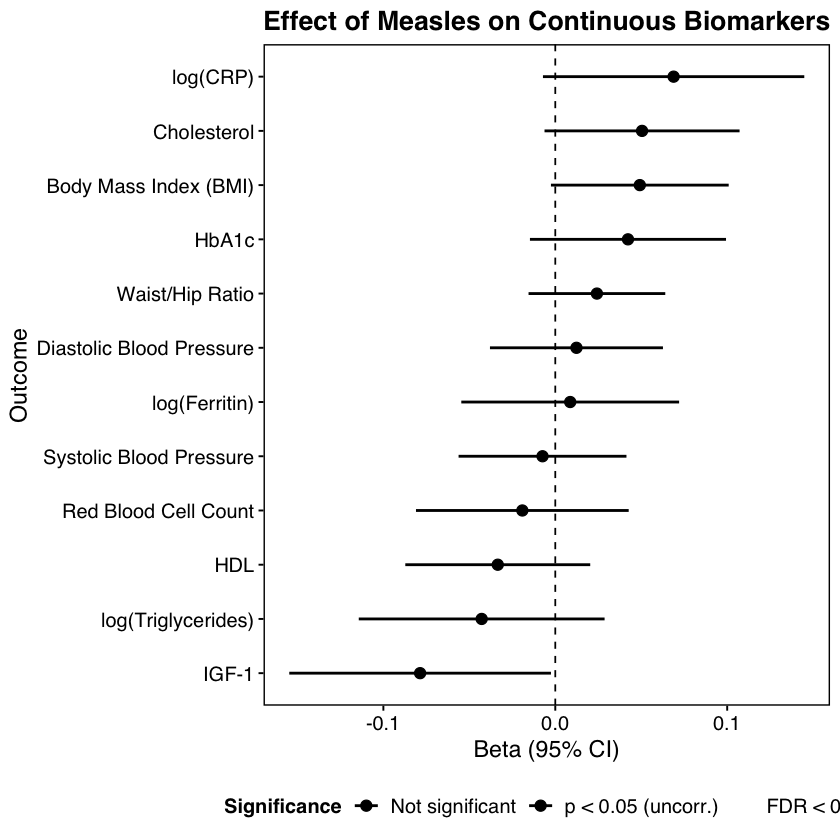

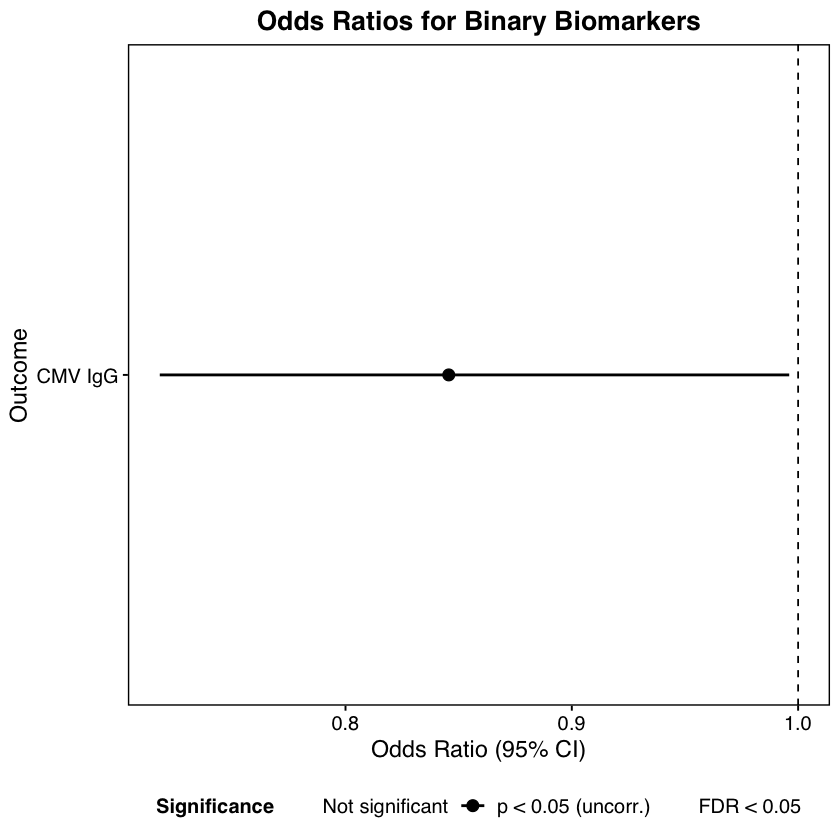

In [39]:
bloodcontinuousplot
bloodcategoricalplot

In [40]:
results_all %>%
  filter(term == "measlesinfectionYes")

term,estimate,std.error,statistic,p.value,conf.low,conf.high,model,outcome,n,family,outcome_label,significant,p_fdr,significant_fdr,sig_status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<fct>
measlesinfectionYes,0.057222534,0.02863933,1.99804032,0.045767474,0.001076609,0.113368459,unadjusted,chol_std,4901,continuous,Cholesterol,TRUE,0.07437214,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,0.050468415,0.02893873,1.74397503,0.081226512,-0.006264539,0.107201369,adjusted,chol_std,4901,continuous,Cholesterol,FALSE,0.21118893,FALSE,Not significant
measlesinfectionYes,-0.064212686,0.02867019,-2.23970229,0.025155039,-0.120419140,-0.008006232,unadjusted,hdl_std,4890,continuous,HDL,TRUE,0.05629793,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,-0.033459528,0.02743552,-1.21956956,0.222687262,-0.087245556,0.020326500,adjusted,hdl_std,4890,continuous,HDL,FALSE,0.34724795,FALSE,Not significant
measlesinfectionYes,0.064087741,0.02877581,2.22713948,0.025983661,0.007674118,0.120501364,unadjusted,hba1c_std,4854,continuous,HbA1c,TRUE,0.05629793,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,0.042284228,0.02909039,1.45354610,0.146137227,-0.014746202,0.099314657,adjusted,hba1c_std,4854,continuous,HbA1c,FALSE,0.31663066,FALSE,Not significant
measlesinfectionYes,-0.108077102,0.03817314,-2.83123411,0.004670568,-0.182928018,-0.033226186,unadjusted,igf1_std,2753,continuous,IGF-1,TRUE,0.02023913,TRUE,FDR < 0.05
measlesinfectionYes,-0.078630651,0.03881665,-2.02569407,0.042893452,-0.154743700,-0.002517602,adjusted,igf1_std,2753,continuous,IGF-1,TRUE,0.21118893,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,0.017351943,0.03819719,0.45427276,0.649668306,-0.057546078,0.092249963,unadjusted,log_frtin_std,2757,continuous,log(Ferritin),FALSE,0.81926521,FALSE,Not significant


In [43]:
write.csv(results_all, "biomarker_all_results.csv", row.names = FALSE)
ggsave("biomarkercontinuousplot.svg", plot = bloodcontinuousplot, device = svglite, width = 6, height = 4)
ggsave("biomarkercategoricalplot.svg", plot = bloodcategoricalplot, device = svglite, width = 6, height = 2)


##### Endpoint regressions

In [42]:
covariates_reg = c("sex", "location", "socialindex",
               "maternal_smoking", "mother_age_at_birth",  
               "older_siblings", "younger_siblings", "income", "parent_ed", "smoking_cat")

In [44]:
categorical_outcomes <- c(
  "diabetes", "hypertension"
)

cognitive_continuous_adult <- c( 
  "wordlist_immediate46_z", "wordlist_delayed46_z",
  "animal_naming46_z", "letter_correct46_z", "letter_speed46_z")

adult_educ <- c("adulteduc")

cognitive_continuous_child <- c(
  "reading_score_raw10_z", "maths_score10_z",
  "maths_score16_z", "matrices_score16_z", "reading_score_total16_z")


In [45]:
## REGRESSIONS AND FOREST PLOTS
# Define families for FDR
OUTCOME_SPEC <- bind_rows(
  tibble(name = categorical_outcomes, type = "binary",     fdr_family = "endpoint"),
  tibble(name = cognitive_continuous_child, type = "continuous", fdr_family = "cognitive"),
  tibble(name = adult_educ, type = "continuous", fdr_family = "adulteduc"),
  tibble(name = cognitive_continuous_adult, type = "continuous", fdr_family = "cognitive")
)

exposure     <- "measlesinfection"
exposure_pat <- paste0("^", exposure)

# ---- single pass loop ----
results_list <- vector("list", nrow(OUTCOME_SPEC))

for (i in seq_len(nrow(OUTCOME_SPEC))) {
  var <- OUTCOME_SPEC$name[i]
  typ <- OUTCOME_SPEC$type[i]
  fam <- OUTCOME_SPEC$fdr_family[i]

  # covariates
  current_covs <- covariates_reg
    if (OUTCOME_SPEC$name[i] %in% cognitive_continuous_child) {
      current_covs <- setdiff(current_covs, "smoking_cat")
    }

  # model data
  cols_needed <- c(var, exposure, current_covs)
  df_model <- df_analytic %>%
    dplyr::select(dplyr::all_of(cols_needed)) %>%
    tidyr::drop_na() %>%
    droplevels()

  # formulas
  f_unadj <- as.formula(paste(var, "~", exposure))
  f_adj   <- as.formula(paste(var, "~", paste(c(exposure, current_covs), collapse = " + ")))

  if (typ == "binary") {
    m_unadj <- glm(f_unadj, data = df_model, family = binomial)
    m_adj   <- glm(f_adj,   data = df_model, family = binomial)

    tid <- bind_rows(
      tidy(m_unadj, exponentiate = TRUE, conf.int = TRUE) %>%
        mutate(model = "unadjusted", n = nobs(m_unadj)),
      tidy(m_adj,   exponentiate = TRUE, conf.int = TRUE) %>%
        mutate(model = "adjusted",   n = nobs(m_adj))
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 1 | conf.high < 1)
      )
} else { # continuous
    m_unadj <- lm(f_unadj, data = df_model)
    m_adj   <- lm(f_adj,   data = df_model)

    tid <- bind_rows(
      tidy(m_unadj, conf.int = TRUE) %>% mutate(model = "unadjusted", n = nobs(m_unadj)),
      tidy(m_adj,   conf.int = TRUE) %>% mutate(model = "adjusted",   n = nobs(m_adj))
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 0 | conf.high < 0)
      )

  }
  results_list[[i]] <- tid
}



# ---- bind + FDR by family ----
all_results <- bind_rows(results_list)

# FDR per (model x fdr_family), ONLY for exposure term rows
all_results <- all_results %>%
  group_by(model, fdr_family) %>%
  mutate(
    .is_exp   = grepl(exposure_pat, term),
    p_fdr     = replace(numeric(n()), .is_exp, p.adjust(p.value[.is_exp], method = "fdr")),
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

#### PLOTS
# ---- adjusted ORs for endpoints ----
forest_df <- all_results %>%
  filter(outcome_type == "binary",
         fdr_family == "endpoint",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

outcomescategoricalor <- ggplot(
  forest_df,
  aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",     # grey
      "p < 0.05 (uncorr.)"    = "black",#
      "FDR < 0.05"            = "black"  # 
    ),
    drop = FALSE
  ) +
  labs(title = "Odds Ratios for Measles Infection (Adjusted)",
       x = "Odds Ratio (95% CI)", y = "Outcome") +
  my_custom_theme()



# ---- Cognitive outcomes (adjusted-only) ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

cognitive_adj_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted)",
    x = "Beta (95% CI)", y = "Outcome") + 
    my_custom_theme()


# ---- adutleduc outcomes (adjusted-only) ----
adult_educ_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "adulteduc",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

adulteduc_adj_plot <- ggplot(
  adult_educ_df,
  aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted)",
    x = "Beta (95% CI)", y = "Outcome") + 
    my_custom_theme()

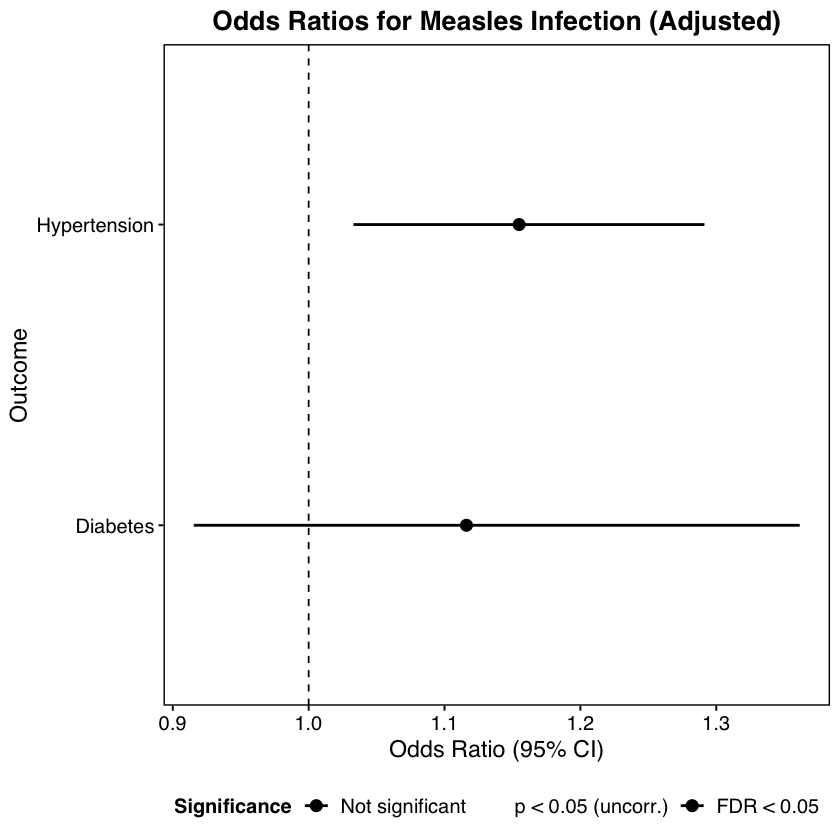

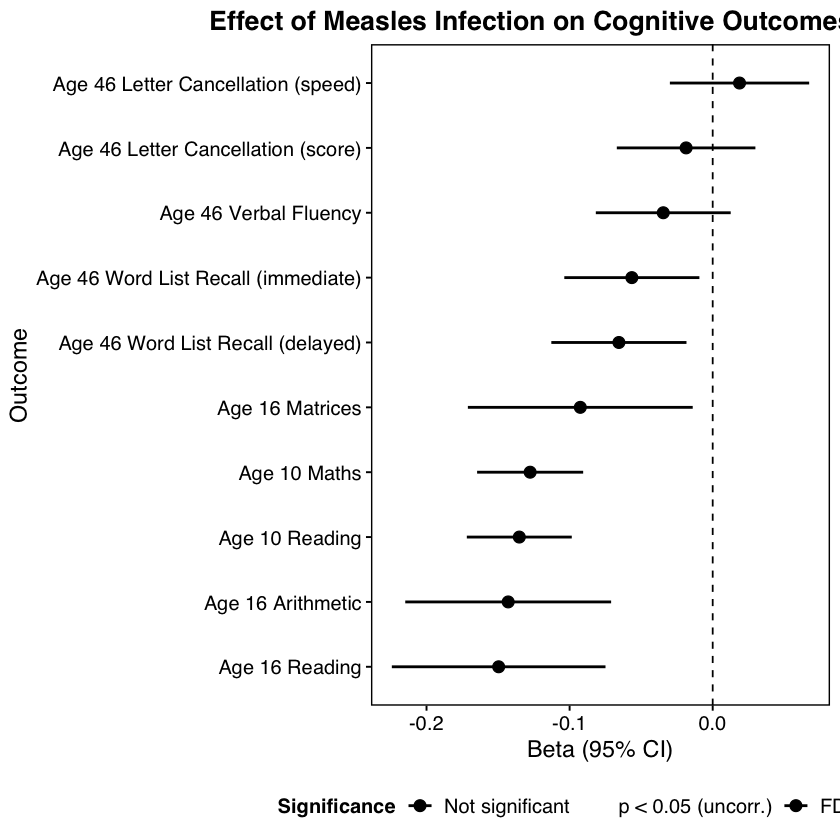

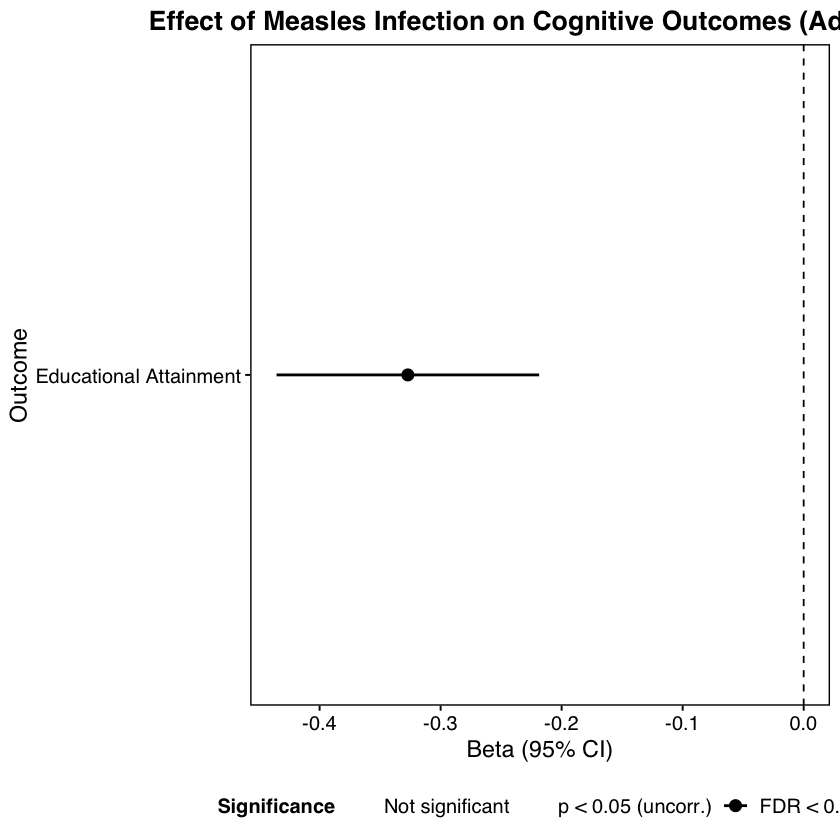

In [46]:
outcomescategoricalor
cognitive_adj_plot
adulteduc_adj_plot

In [47]:
all_results %>%
  filter(term == "measlesinfectionYes")

term,estimate,std.error,statistic,p.value,conf.low,conf.high,model,n,outcome,outcome_type,fdr_family,significant,p_fdr,significant_fdr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>
measlesinfectionYes,1.219770505,0.09842293,2.0184599,4.354339e-02,1.00594691,1.479924734,unadjusted,7005,diabetes,binary,endpoint,TRUE,4.354339e-02,TRUE
measlesinfectionYes,1.116140398,0.10118449,1.0859041,2.775214e-01,0.91544965,1.361424397,adjusted,7005,diabetes,binary,endpoint,FALSE,2.775214e-01,FALSE
measlesinfectionYes,1.223050983,0.05532379,3.6394570,2.732136e-04,1.09742153,1.363225553,unadjusted,7349,hypertension,binary,endpoint,TRUE,5.464271e-04,TRUE
measlesinfectionYes,1.154902352,0.05692993,2.5297026,1.141592e-02,1.03298352,1.291286098,adjusted,7349,hypertension,binary,endpoint,TRUE,2.283185e-02,TRUE
measlesinfectionYes,-0.262167144,0.01984276,-13.2122287,1.599406e-39,-0.30106296,-0.223271325,unadjusted,9986,reading_score_raw10_z,continuous,cognitive,TRUE,1.599406e-38,TRUE
measlesinfectionYes,-0.135161705,0.01871043,-7.2238700,5.423137e-13,-0.17183793,-0.098485481,adjusted,9986,reading_score_raw10_z,continuous,cognitive,TRUE,5.423137e-12,TRUE
measlesinfectionYes,-0.237450650,0.01987798,-11.9454144,1.145165e-32,-0.27641549,-0.198485809,unadjusted,9982,maths_score10_z,continuous,cognitive,TRUE,5.725826e-32,TRUE
measlesinfectionYes,-0.127586571,0.01890739,-6.7479724,1.582722e-11,-0.16464889,-0.090524254,adjusted,9982,maths_score10_z,continuous,cognitive,TRUE,7.913610e-11,TRUE
measlesinfectionYes,-0.233301624,0.03810723,-6.1222399,1.055188e-09,-0.30802354,-0.158579703,unadjusted,2733,maths_score16_z,continuous,cognitive,TRUE,2.637969e-09,TRUE


In [48]:
# ---- save ----
write.csv(all_results, "all_outcomes_fdr_by_family.csv", row.names = FALSE)

ggsave("outcomescategoricalor.svg", plot = outcomescategoricalor, device = svglite, width = 6, height = 3)

ggsave("cognitive_adjusted_plot.svg", plot = cognitive_adj_plot, device = svglite, width = 6, height = 5)

ggsave("adulteduc_adj_plot.svg", plot = adulteduc_adj_plot, device = svglite, width = 6, height = 3)

## Sensitivity analyses

Stratify all results by sex

In [49]:
sex_var <- "sex"
sex_levels <- df_analytic %>%
  pull(!!rlang::sym(sex_var)) %>%
  unique() %>% na.omit() %>% as.character()

# --- helper: same logic as your fit_once but run on a provided df_sub and add sex ---
fit_once_sex <- function(y, sex_value) {
  fam <- family_map[[y]]

  # subset data for this sex
  df_sub <- df_analytic %>%
    dplyr::filter(!!rlang::sym(sex_var) == sex_value)

  # remove sex from covariates (we're stratifying)
  covs <- setdiff(covariates_reg, sex_var)

  # variables that will be used in the models (exclude outcome)
  preds <- unique(c("measlesinfection", covs))

  # check that every predictor has >= 2 non-NA unique values inside df_sub
  pred_ok <- sapply(preds, function(v) {
    if (!v %in% names(df_sub)) return(FALSE)
    length(unique(na.omit(df_sub[[v]]))) >= 2
  })

  if (!all(pred_ok)) {
    warning(sprintf(
      "Skipping outcome=%s, sex=%s because predictors with <2 levels: %s",
      y, sex_value, paste(names(pred_ok)[!pred_ok], collapse = ", ")
    ))
    return(tibble())   # skip this stratum
  }

  # build formulas
  f_unadj <- as.formula(paste(y, "~ measlesinfection"))
  f_adj   <- as.formula(paste(y, "~", paste(c("measlesinfection", covs), collapse = " + ")))

  # safe fit
  safe_fit <- function(fml) tryCatch({
    if (fam == "binomial") glm(fml, data = df_sub, family = binomial) else lm(fml, data = df_sub)
  }, error = function(e) NULL)

  m_unadj <- safe_fit(f_unadj)
  m_adj   <- safe_fit(f_adj)

  bind_rows(
    if (!is.null(m_unadj)) broom::tidy(m_unadj, conf.int = TRUE, exponentiate = (fam == "binomial")) %>%
      mutate(model = "unadjusted", outcome = y, n = nobs(m_unadj)) else tibble(),
    if (!is.null(m_adj))   broom::tidy(m_adj,   conf.int = TRUE, exponentiate = (fam == "binomial")) %>%
      mutate(model = "adjusted",   outcome = y, n = nobs(m_adj))   else tibble()
  ) %>%
    mutate(
      family = fam,
      outcome_label = label_map[outcome],
      sex = sex_value,
      significant = case_when(
        grepl("^measlesinfection", term) & family == "continuous" ~ conf.low > 0 | conf.high < 0,
        grepl("^measlesinfection", term) & family == "binomial"    ~ conf.low > 1 | conf.high < 1,
        TRUE ~ FALSE
      )
    )
}



# --- Run for every sex x outcome (very simple) ---
results_all <- purrr::map_dfr(sex_levels, function(s) {
  purrr::map_dfr(outcomes, function(y) fit_once_sex(y, s))
})

# --- Apply FDR within each (model x sex) group for exposure rows ---
results_all <- results_all %>%
  group_by(model, sex) %>%
  mutate(
    .is_exp = grepl("^measlesinfection", term),
    p_fdr = {
      idx <- .is_exp
      tmp <- rep(NA_real_, n())
      if (any(idx)) tmp[idx] <- p.adjust(p.value[idx], method = "fdr")
      tmp
    },
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

# --- sig_status factors (same as your original) ---
results_all <- results_all %>%
  mutate(
    sig_status = case_when(
      grepl("^measlesinfection", term) & significant_fdr ~ "FDR < 0.05",
      grepl("^measlesinfection", term) & significant     ~ "p < 0.05 (uncorr.)",
      grepl("^measlesinfection", term)                   ~ "Not significant",
      TRUE                                               ~ NA_character_
    ),
    sig_status = factor(sig_status, levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

# --- Plots faceted by sex (minimal change) ---
sexbloodcontinuousplot <- results_all %>%
  filter(family == "continuous", model == "adjusted", grepl("^measlesinfection", term)) %>%
  ggplot(aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 2.8) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c("Not significant" = "black", "p < 0.05 (uncorr.)" = "black", "FDR < 0.05" = "black"),
    drop = FALSE
  ) +
  labs(title = "Effect of Measles on Continuous Biomarkers (Adjusted)",
       x = "Beta (95% CI)", y = "Outcome") +
  facet_wrap(vars(!!rlang::sym(sex_var)), scales = "free_y") +
  my_custom_theme()

sexbloodcategoricalplot <- results_all %>%
  filter(family == "binomial", model == "adjusted", grepl("^measlesinfection", term)) %>%
  ggplot(aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c("Not significant" = "black", "p < 0.05 (uncorr.)" = "black", "FDR < 0.05" = "black"),
    drop = FALSE
  ) +
  labs(title = "Odds Ratios for Binary Biomarkers (Adjusted)",
       x = "Odds Ratio (95% CI)", y = "Outcome") +
  facet_wrap(vars(!!rlang::sym(sex_var)), scales = "free_y") +
  my_custom_theme()


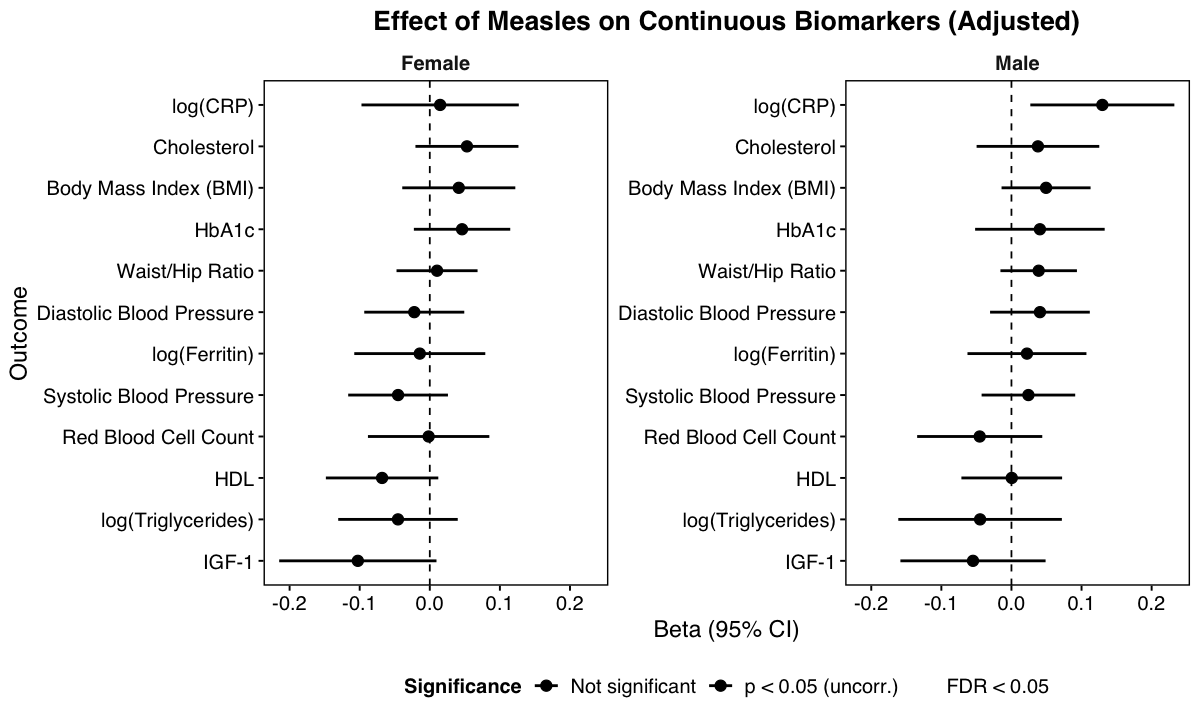

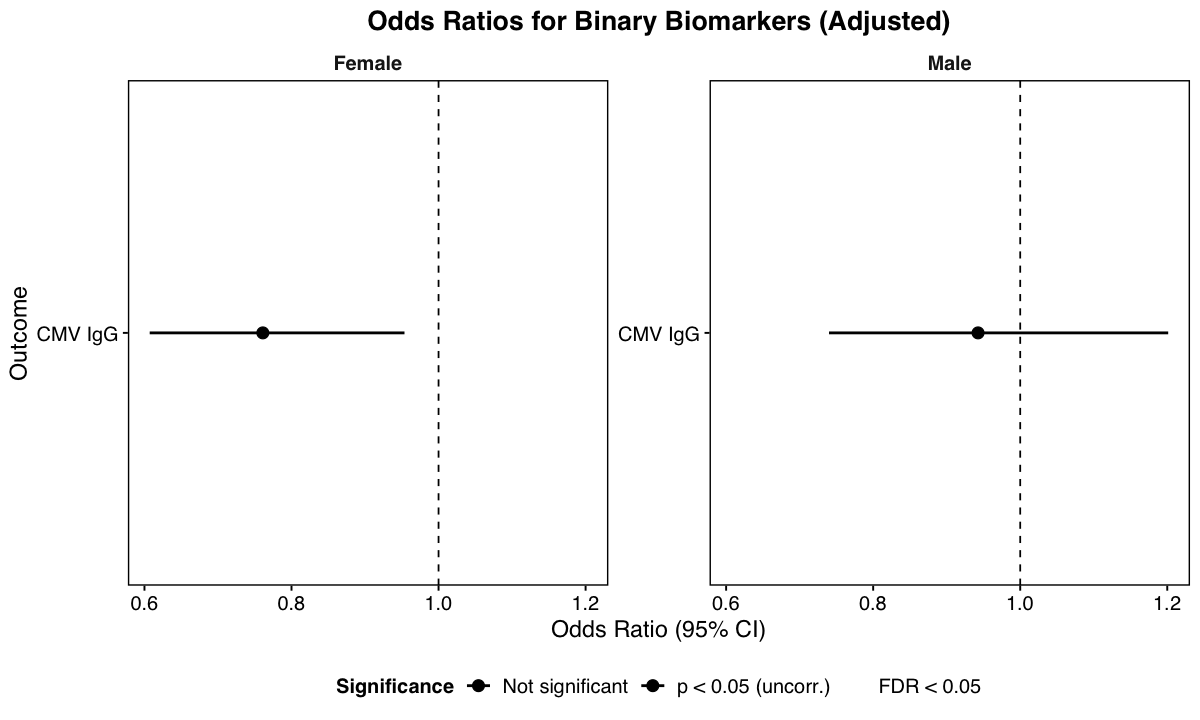

In [50]:
options(repr.plot.width = 10, repr.plot.height = 6)
sexbloodcontinuousplot
sexbloodcategoricalplot

In [51]:
results_all  %>%
  filter(term == "measlesinfectionYes")

term,estimate,std.error,statistic,p.value,conf.low,conf.high,model,outcome,n,family,outcome_label,sex,significant,p_fdr,significant_fdr,sig_status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<fct>
measlesinfectionYes,0.0759203265,0.03657393,2.07580449,0.038013342,0.004202255,0.147638398,unadjusted,chol_std,2519,continuous,Cholesterol,Female,TRUE,0.09883469,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,0.0530045042,0.03747274,1.41448160,0.157345524,-0.020476424,0.126485433,adjusted,chol_std,2519,continuous,Cholesterol,Female,FALSE,0.46059579,FALSE,Not significant
measlesinfectionYes,-0.1023510486,0.04006624,-2.55454616,0.010691041,-0.180917223,-0.023784874,unadjusted,hdl_std,2518,continuous,HDL,Female,TRUE,0.05695714,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,-0.0680621881,0.04089895,-1.66415479,0.096207324,-0.148261646,0.012137270,adjusted,hdl_std,2518,continuous,HDL,Female,FALSE,0.41689840,FALSE,Not significant
measlesinfectionYes,0.0559145962,0.03427643,1.63128403,0.102957066,-0.011298700,0.123127893,unadjusted,hba1c_std,2488,continuous,HbA1c,Female,FALSE,0.22307364,FALSE,Not significant
measlesinfectionYes,0.0460261851,0.03506114,1.31274060,0.189392822,-0.022726218,0.114778588,adjusted,hba1c_std,2488,continuous,HbA1c,Female,FALSE,0.46059579,FALSE,Not significant
measlesinfectionYes,-0.1391362992,0.05603564,-2.48299673,0.013143955,-0.249058618,-0.029213981,unadjusted,igf1_std,1410,continuous,IGF-1,Female,TRUE,0.05695714,FALSE,p < 0.05 (uncorr.)
measlesinfectionYes,-0.1026568984,0.05719717,-1.79478994,0.072905631,-0.214859551,0.009545754,adjusted,igf1_std,1410,continuous,IGF-1,Female,FALSE,0.41689840,FALSE,Not significant
measlesinfectionYes,-0.0100296856,0.04694731,-0.21363708,0.830860949,-0.102123716,0.082064344,unadjusted,log_frtin_std,1413,continuous,log(Ferritin),Female,FALSE,0.90068597,FALSE,Not significant


In [52]:
write.csv(results_all, "biomarker_sex_results.csv", row.names = FALSE)
ggsave("sexbiomarkercontinuousplot.svg", plot = sexbloodcontinuousplot, device = svglite, width = 10, height = 4)
ggsave("sexbiomarkercategoricalplot.svg", plot = sexbloodcategoricalplot, device = svglite, width = 10, height = 3)


In [53]:
## REGRESSIONS AND FOREST PLOTS — stratified by sex (minimal changes)

# OUTCOME_SPEC and exposure as before
OUTCOME_SPEC <- bind_rows(
  tibble(name = categorical_outcomes, type = "binary",     fdr_family = "endpoint"),
  tibble(name = cognitive_continuous_child, type = "continuous", fdr_family = "cognitive"),
  tibble(name = cognitive_continuous_adult, type = "continuous", fdr_family = "cognitive"),
  tibble(name = adult_educ, type = "continuous", fdr_family = "adulteduc")
)

exposure     <- "measlesinfection"
exposure_pat <- paste0("^", exposure)

# sex variable and levels (change name if needed)
sex_var <- "sex"
sex_levels <- df_analytic %>%
  dplyr::pull(!!rlang::sym(sex_var)) %>%
  unique() %>% na.omit() %>% as.character()

# storage
results_list <- list()

# ---- nested loop: outcomes x sex ----
for (i in seq_len(nrow(OUTCOME_SPEC))) {
  var <- OUTCOME_SPEC$name[i]
  typ <- OUTCOME_SPEC$type[i]
  fam <- OUTCOME_SPEC$fdr_family[i]

  # covariates for this outcome
  current_covs <- covariates_reg
  if (var %in% cognitive_continuous_child) {
    current_covs <- setdiff(current_covs, "smoking_cat")
  }
  # ensure sex not included as covariate when stratifying
  current_covs <- setdiff(current_covs, sex_var)

  # loop sexes
  for (s in sex_levels) {

    # model data for this stratum
    cols_needed <- c(var, exposure, current_covs, sex_var)
    df_model <- df_analytic %>%
      dplyr::select(dplyr::all_of(cols_needed)) %>%
      tidyr::drop_na() %>%
      dplyr::filter(!!rlang::sym(sex_var) == s) %>%
      droplevels()

    # skip empty stratum
    if (nrow(df_model) == 0) next

    # quick predictor-level check to avoid contrasts error
    preds <- unique(c(exposure, current_covs))
    pred_ok <- sapply(preds, function(v) {
      if (!v %in% names(df_model)) return(FALSE)
      length(unique(na.omit(df_model[[v]]))) >= 2
    })
    if (!all(pred_ok)) {
      warning(sprintf("Skipping outcome=%s, sex=%s because predictors with <2 levels: %s",
                      var, s, paste(names(pred_ok)[!pred_ok], collapse = ", ")))
      next
    }

    # formulas (sex not added because we stratified)
    f_unadj <- as.formula(paste(var, "~", exposure))
    f_adj   <- as.formula(paste(var, "~", paste(c(exposure, current_covs), collapse = " + ")))

    # fit models and tidy (binary and continuous branches as in original)
    if (typ == "binary") {
      m_unadj <- glm(f_unadj, data = df_model, family = binomial)
      m_adj   <- glm(f_adj,   data = df_model, family = binomial)

      tid <- bind_rows(
        tidy(m_unadj, exponentiate = TRUE, conf.int = TRUE) %>%
          mutate(model = "unadjusted", n = nobs(m_unadj)),
        tidy(m_adj,   exponentiate = TRUE, conf.int = TRUE) %>%
          mutate(model = "adjusted",   n = nobs(m_adj))
      ) %>%
        mutate(
          outcome      = var,
          outcome_type = typ,
          fdr_family   = fam,
          significant  = grepl(exposure_pat, term) & (conf.low > 1 | conf.high < 1),
          sex = s
        )
    } else { # continuous
      m_unadj <- lm(f_unadj, data = df_model)
      m_adj   <- lm(f_adj,   data = df_model)

      tid <- bind_rows(
        tidy(m_unadj, conf.int = TRUE) %>% mutate(model = "unadjusted", n = nobs(m_unadj)),
        tidy(m_adj,   conf.int = TRUE) %>% mutate(model = "adjusted",   n = nobs(m_adj))
      ) %>%
        mutate(
          outcome      = var,
          outcome_type = typ,
          fdr_family   = fam,
          significant  = grepl(exposure_pat, term) & (conf.low > 0 | conf.high < 0),
          sex = s
        )
    }

    # vectorized label lookup (avoids [[ multi-index error])
    tid <- tid %>% mutate(outcome_label = label_map[outcome])

    # append
    results_list[[length(results_list) + 1]] <- tid
  } # end sex loop
} # end outcome loop

# ---- bind + FDR by (model x fdr_family x sex) ----
all_results <- bind_rows(results_list)

# If nothing ran, give a helpful error
if (nrow(all_results) == 0) stop("No models were fit for any sex stratum. Check predictors / strata sizes.")

all_results <- all_results %>%
  group_by(model, fdr_family, sex) %>%
  mutate(
    .is_exp   = grepl(exposure_pat, term),
    p_fdr     = replace(numeric(n()), .is_exp, p.adjust(p.value[.is_exp], method = "fdr")),
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

#### PLOTS (faceted by sex)
# ---- adjusted ORs for endpoints ----
forest_df <- all_results %>%
  filter(outcome_type == "binary",
         fdr_family == "endpoint",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",
      significant     ~ "p < 0.05 (uncorr.)",
      TRUE            ~ "Not significant"
    ),
    sig_status = factor(sig_status, levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

sexoutcomescategoricalor <- ggplot(
  forest_df,
  aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c("Not significant" = "black","p < 0.05 (uncorr.)" = "black","FDR < 0.05" = "black"),
    drop = FALSE
  ) +
  labs(title = "Odds Ratios for Measles Infection (Adjusted) — stratified by sex",
       x = "Odds Ratio (95% CI)", y = "Outcome") +
  facet_wrap(vars(sex), scales = "free_y", ncol = 1) +
  my_custom_theme()

# ---- Cognitive outcomes (adjusted-only) ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",
      significant     ~ "p < 0.05 (uncorr.)",
      TRUE            ~ "Not significant"
    ),
    sig_status = factor(sig_status, levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

sexcognitive_adj_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c("Not significant" = "black","p < 0.05 (uncorr.)" = "black","FDR < 0.05" = "black"),
    drop = FALSE
  ) +
  labs(title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted) — stratified by sex",
       x = "Beta (95% CI)", y = "Outcome") +
  facet_wrap(vars(sex), scales = "free_y", ncol = 1) +
  my_custom_theme()

# ---- adulteduc outcomes (adjusted-only) ----
adult_educ_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "adulteduc",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",
      significant     ~ "p < 0.05 (uncorr.)",
      TRUE            ~ "Not significant"
    ),
    sig_status = factor(sig_status, levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

sexadult_educ_plot <- ggplot(
  adult_educ_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c("Not significant" = "black","p < 0.05 (uncorr.)" = "black","FDR < 0.05" = "black"),
    drop = FALSE
  ) +
  labs(title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted) — stratified by sex",
       x = "Beta (95% CI)", y = "Outcome") +
  facet_wrap(vars(sex), scales = "free_y", ncol = 1) +
  my_custom_theme()

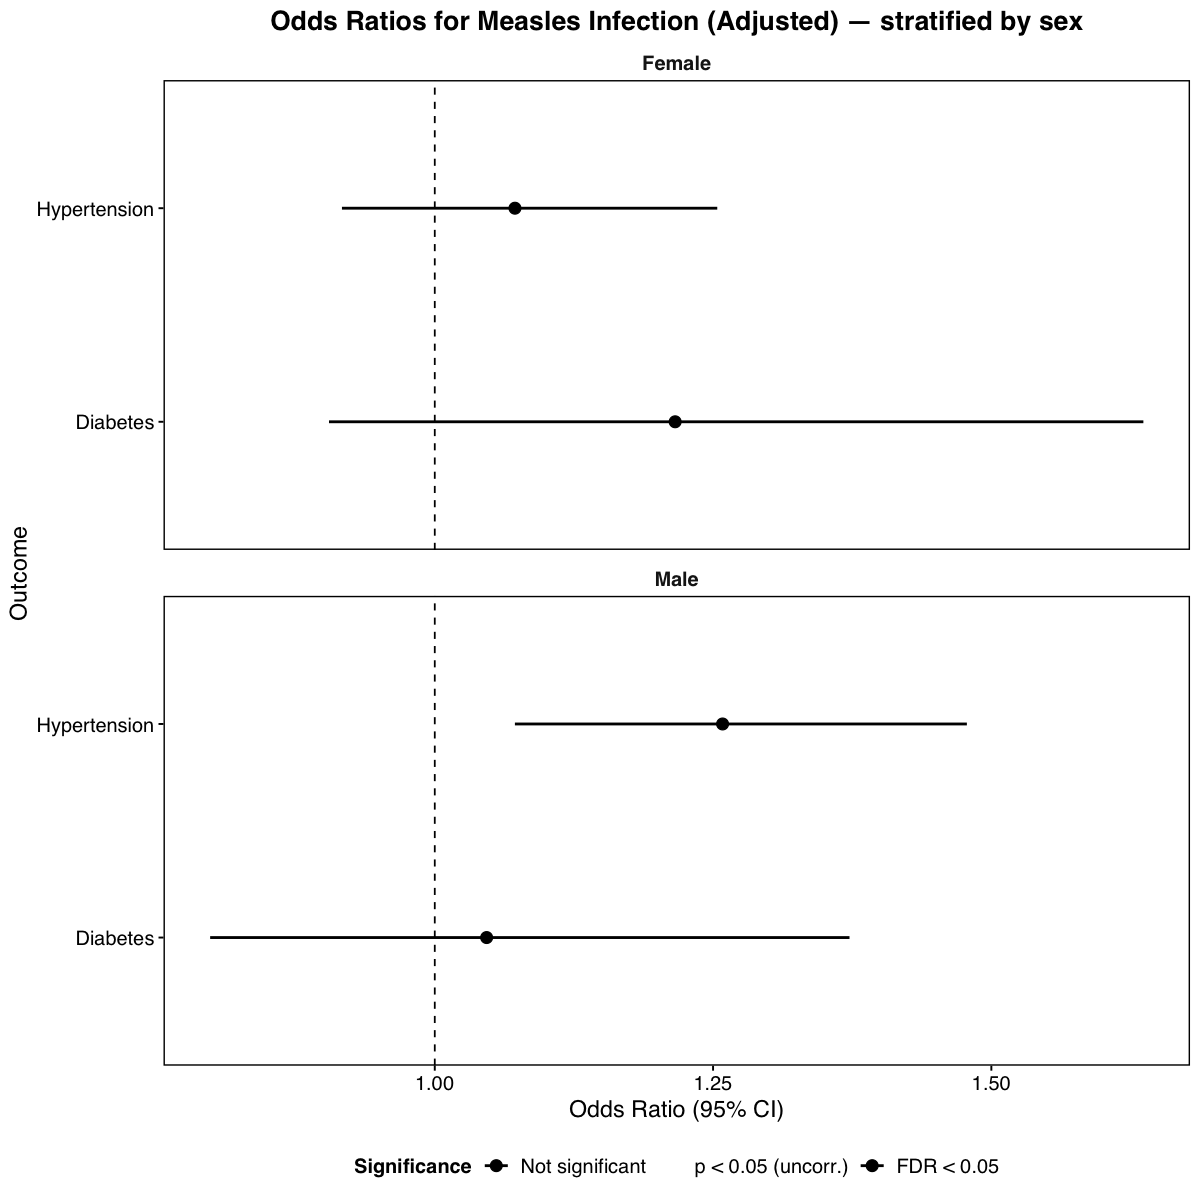

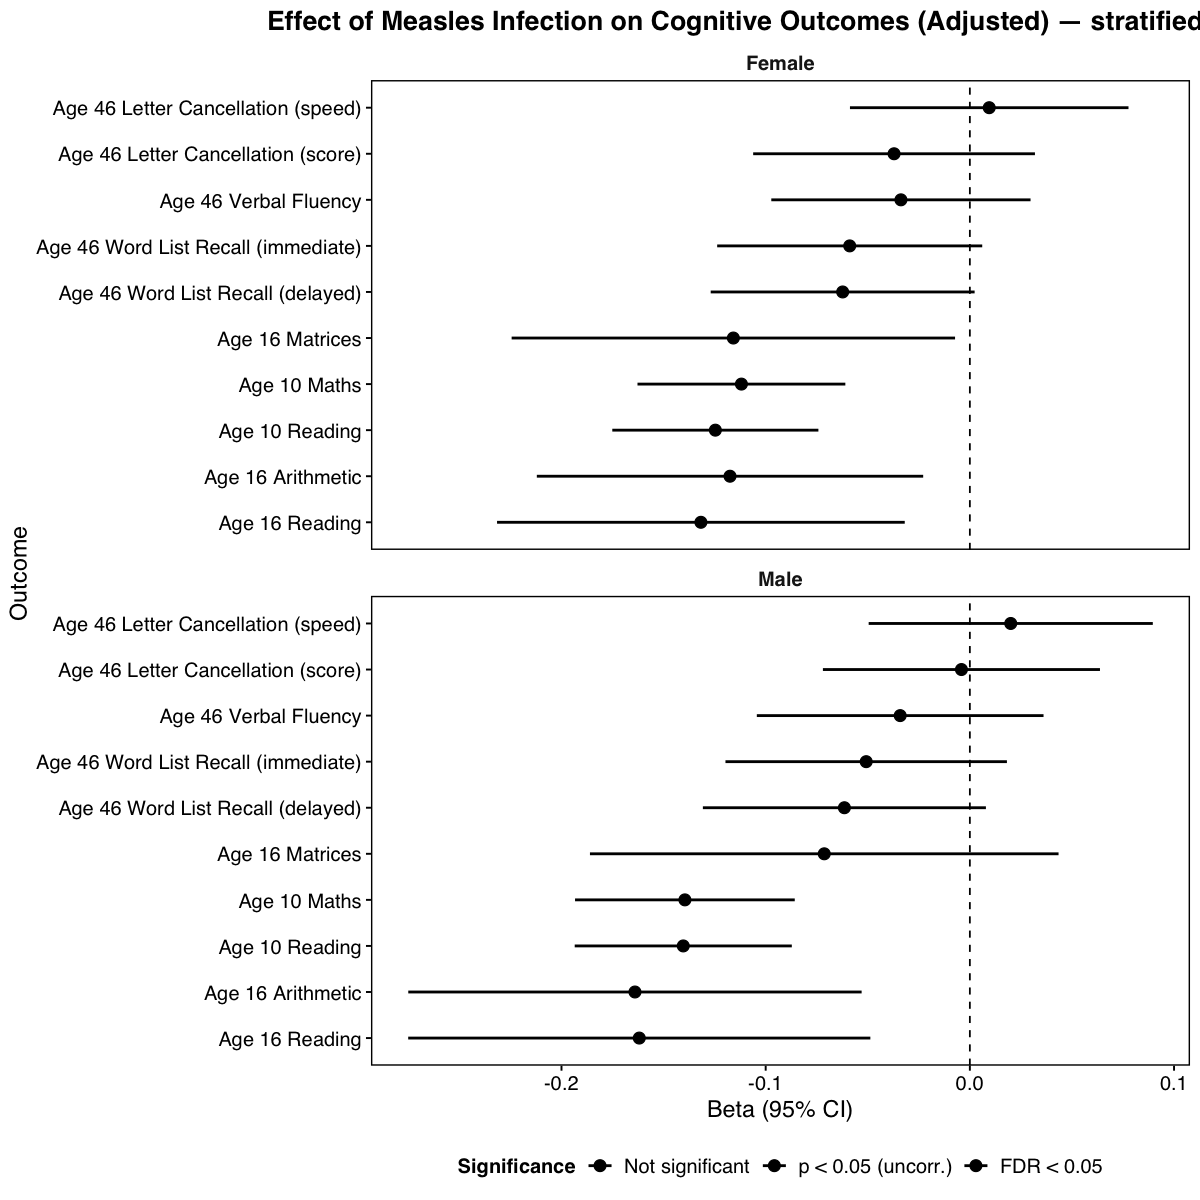

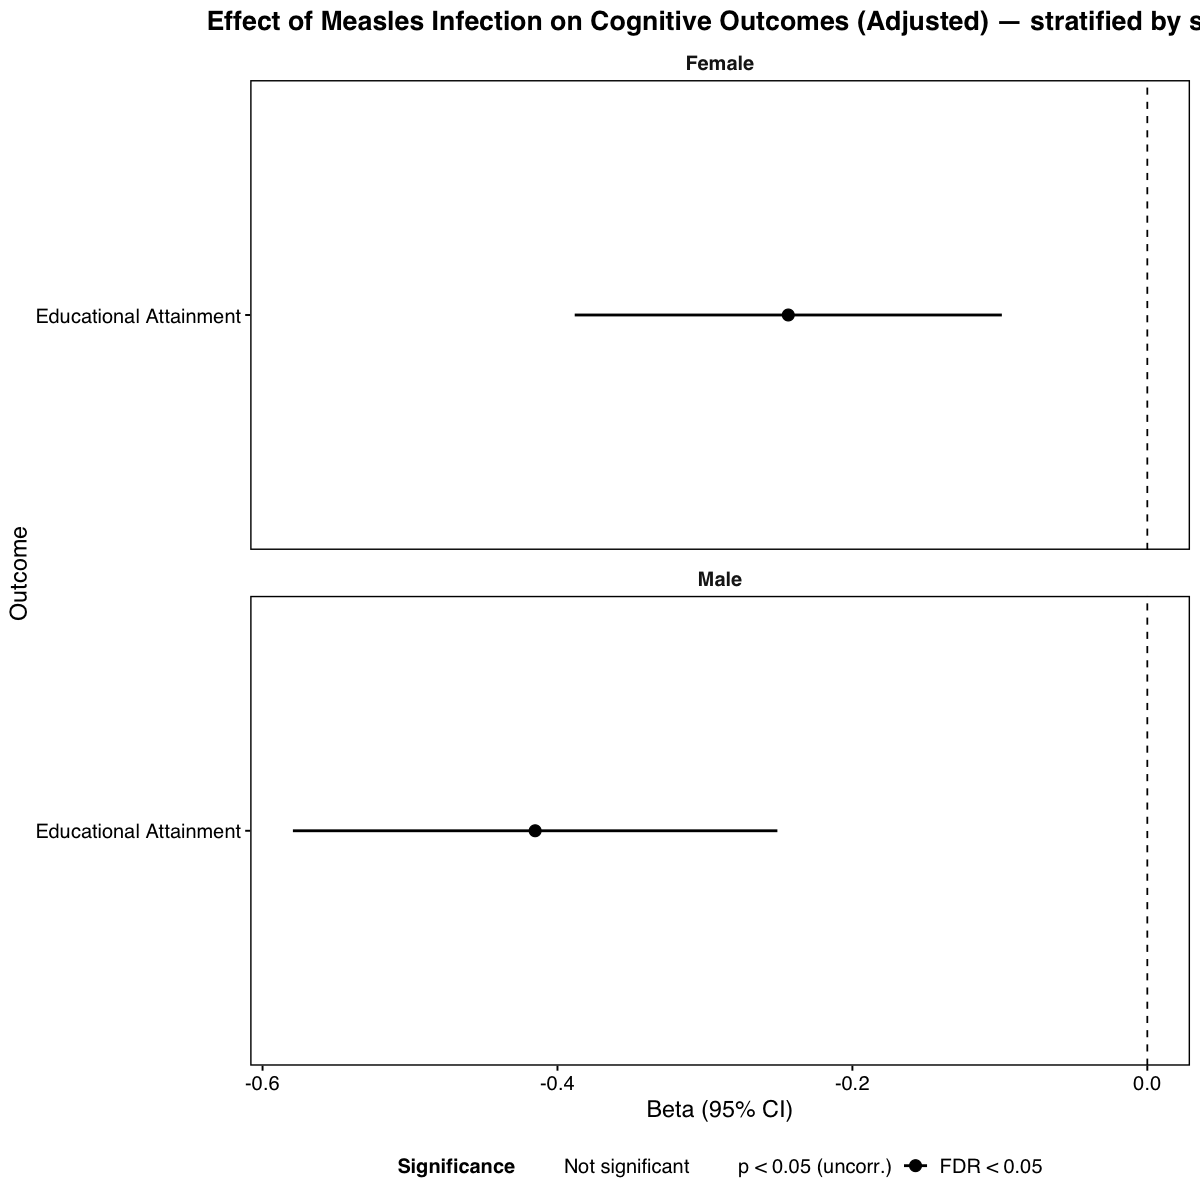

In [54]:
options(repr.plot.width = 10, repr.plot.height = 10)
sexoutcomescategoricalor
sexcognitive_adj_plot
sexadult_educ_plot

In [56]:
# ---- save ----
write.csv(all_results, "all_outcomes_sex.csv", row.names = FALSE)
ggsave("sexoutcomescategoricalor.svg", plot = sexoutcomescategoricalor, device = svglite, width = 10, height = 5)

ggsave("sexcognitive_adjusted_plot.svg", plot = sexcognitive_adj_plot, device = svglite, width = 10, height = 10)

ggsave("sexadulteduc_adjusted_plot.svg", plot = adulteduc_adj_plot, device = svglite, width = 10, height = 3)


Stratification of cognitive effects by SES

In [108]:
cognitive_continuous_adult <- c( 
  "wordlist_immediate46_z", "wordlist_delayed46_z",
  "animal_naming46_z", "letter_correct46_z", "letter_speed46_z", "adulteduc")

OUTCOME_SPEC <- bind_rows(
  tibble(name = cognitive_continuous_child, type = "continuous", fdr_family = "cognitive"),
  tibble(name = cognitive_continuous_adult, type = "continuous", fdr_family = "cognitive"),
)

In [109]:
## ONLY COGNITIVE OUTCOMES, STRATIFIED BY INCOME
# get only cognitive outcomes
cog_outcomes <- OUTCOME_SPEC %>%
  filter(fdr_family == "cognitive") %>%
  pull(name)

exposure     <- "measlesinfection"
exposure_pat <- paste0("^", exposure)

# income variable (change name if needed)
income_var <- "income"
income_levels <- df_analytic %>%
  dplyr::pull(!!rlang::sym(income_var)) %>%
  unique() %>%
  na.omit() %>%
  as.character()

# prepare storage
results_list <- vector("list", length(cog_outcomes))

# loop outcomes
for (i in seq_along(cog_outcomes)) {
  var <- cog_outcomes[i]
  typ <- "continuous"
  fam <- "cognitive"

  # covariates for this outcome
  current_covs <- covariates_reg
  if (var %in% cognitive_continuous_child) {
    current_covs <- setdiff(current_covs, "smoking_cat")
  }

  # ensure income not treated as covariate (we're stratifying)
  current_covs <- setdiff(current_covs, income_var)

  # collect per-income-stratum results
  per_income <- vector("list", length(income_levels))

  for (j in seq_along(income_levels)) {
    inc_level <- income_levels[j]

    # subset and drop NA
    cols_needed <- c(var, exposure, current_covs, income_var)
    df_model <- df_analytic %>%
      dplyr::select(dplyr::all_of(cols_needed)) %>%
      tidyr::drop_na() %>%
      dplyr::filter(!!rlang::sym(income_var) == inc_level) %>%
      droplevels()

    if (nrow(df_model) == 0) {
      per_income[[j]] <- tibble()
      next
    }

    # formulas
    f_unadj <- as.formula(paste(var, "~", exposure))
    f_adj   <- as.formula(paste(var, "~", paste(c(exposure, current_covs), collapse = " + ")))

    # fit with tryCatch to avoid breaking pipeline if a stratum fails
    fit_safe <- function(fml) {
      tryCatch(lm(fml, data = df_model), error = function(e) NULL)
    }

    m_unadj <- fit_safe(f_unadj)
    m_adj   <- fit_safe(f_adj)

    tid <- bind_rows(
      if (!is.null(m_unadj)) broom::tidy(m_unadj, conf.int = TRUE) %>% mutate(model = "unadjusted", n = nobs(m_unadj)) else tibble(),
      if (!is.null(m_adj))   broom::tidy(m_adj,   conf.int = TRUE) %>% mutate(model = "adjusted",   n = nobs(m_adj))   else tibble()
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 0 | conf.high < 0),
        !!income_var := inc_level
      )

    per_income[[j]] <- tid
  } # end income loop

  results_list[[i]] <- bind_rows(per_income)
} # end outcome loop

# ---- bind + FDR by (model x fdr_family x income) ----
all_results <- bind_rows(results_list)

# ensure income column exists
if (!income_var %in% names(all_results)) all_results[[income_var]] <- NA_character_

# FDR per (model x fdr_family x income) for exposure rows only
all_results <- all_results %>%
  group_by(model, fdr_family, !!rlang::sym(income_var)) %>%
  mutate(
    .is_exp   = grepl(exposure_pat, term),
    p_fdr     = replace(numeric(n()), .is_exp, if (any(.is_exp)) p.adjust(p.value[.is_exp], method = "fdr") else rep(NA_real_, sum(.is_exp))),
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

# ---- cognitive-only adjusted plot, faceted by income ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

cognitive_adj_by_income_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted) — stratified by income",
    x = "Beta (95% CI)", y = "Outcome"
  ) +
  facet_wrap(vars(!!rlang::sym(income_var)), scales = "free_y", ncol = 1) +
  my_custom_theme()


      # ---- cognitive-only adjusted plot, faceted by income ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

cognitive_adj_by_income_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted) — stratified by income",
    x = "Beta (95% CI)", y = "Outcome"
  ) +
  facet_wrap(vars(!!rlang::sym(income_var)), scales = "free_y", ncol = 1) +
  my_custom_theme()

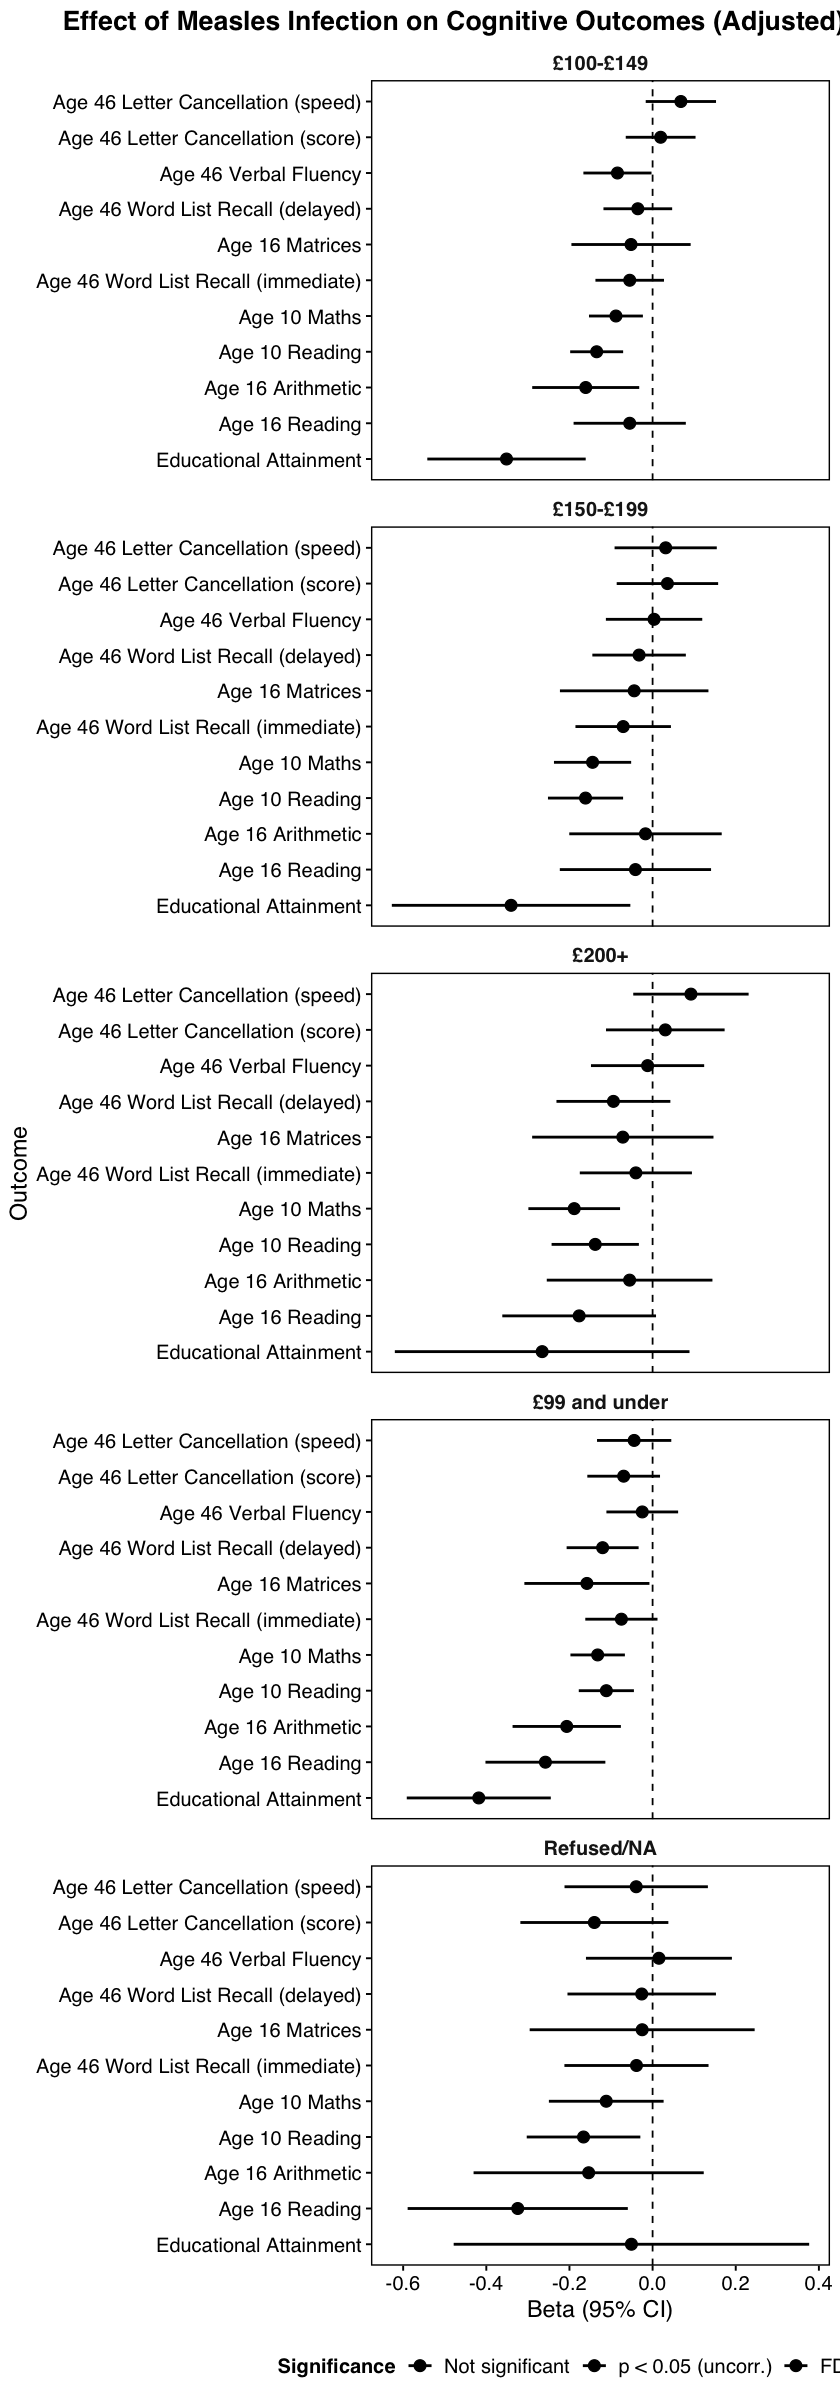

In [110]:
options(repr.plot.width = 7, repr.plot.height = 20)
cognitive_adj_by_income_plot

In [111]:
cog_adj_df

term,estimate,std.error,statistic,p.value,conf.low,conf.high,model,n,outcome,outcome_type,fdr_family,significant,income,p_fdr,significant_fdr,outcome_label,sig_status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<lgl>,<chr>,<fct>
measlesinfectionYes,-0.111273499,0.03382698,-3.28948923,1.014066e-03,-0.17759711,-0.044949888,adjusted,3377,reading_score_raw10_z,continuous,cognitive,TRUE,£99 and under,2.788681e-03,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.134563678,0.03249305,-4.14130693,3.542439e-05,-0.19827294,-0.070854418,adjusted,3229,reading_score_raw10_z,continuous,cognitive,TRUE,£100-£149,3.896682e-04,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.138001177,0.05350497,-2.57922167,1.004031e-02,-0.24299260,-0.033009750,adjusted,1052,reading_score_raw10_z,continuous,cognitive,TRUE,£200+,5.522173e-02,FALSE,Age 10 Reading,p < 0.05 (uncorr.)
measlesinfectionYes,-0.161333018,0.04606591,-3.50222120,4.749672e-04,-0.25169366,-0.070972380,adjusted,1520,reading_score_raw10_z,continuous,cognitive,TRUE,£150-£199,5.224639e-03,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.166134152,0.06961133,-2.38659628,1.724138e-02,-0.30278081,-0.029487490,adjusted,808,reading_score_raw10_z,continuous,cognitive,TRUE,Refused/NA,9.482759e-02,FALSE,Age 10 Reading,p < 0.05 (uncorr.)
measlesinfectionYes,-0.132156687,0.03340947,-3.95566530,7.790144e-05,-0.19766170,-0.066651673,adjusted,3376,maths_score10_z,continuous,cognitive,TRUE,£99 and under,4.284579e-04,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.088181521,0.03306926,-2.66657085,7.701412e-03,-0.15302054,-0.023342502,adjusted,3232,maths_score10_z,continuous,cognitive,TRUE,£100-£149,2.823851e-02,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.188535959,0.05619342,-3.35512491,8.223740e-04,-0.29880325,-0.078268665,adjusted,1049,maths_score10_z,continuous,cognitive,TRUE,£200+,9.046114e-03,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.144420824,0.04733380,-3.05111408,2.320181e-03,-0.23726874,-0.051572910,adjusted,1515,maths_score10_z,continuous,cognitive,TRUE,£150-£199,1.276099e-02,TRUE,Age 10 Maths,FDR < 0.05


In [112]:
# ---- save ----
write.csv(all_results, "cog_adj_ses.csv", row.names = FALSE)

ggsave("cognitive_ses_plot.svg", plot = cognitive_adj_by_income_plot, device = svglite, width = 7, height = 20)


Cog stratified by parental education

In [113]:
## ONLY COGNITIVE OUTCOMES, STRATIFIED BY parent education
# get only cognitive outcomes
cog_outcomes <- OUTCOME_SPEC %>%
  filter(fdr_family == "cognitive") %>%
  pull(name)

exposure     <- "measlesinfection"
exposure_pat <- paste0("^", exposure)

# income variable (change name if needed)
parented_var <- "parent_ed"
parented_levels <- df_analytic %>%
  dplyr::pull(!!rlang::sym(parented_var)) %>%
  unique() %>%
  na.omit() %>%
  as.character()

# prepare storage
results_list <- vector("list", length(cog_outcomes))

# loop outcomes
for (i in seq_along(cog_outcomes)) {
  var <- cog_outcomes[i]
  typ <- "continuous"
  fam <- "cognitive"

  # covariates for this outcome
  current_covs <- covariates_reg
  if (var %in% cognitive_continuous_child) {
    current_covs <- setdiff(current_covs, "smoking_cat")
  }

  # ensure parented not treated as covariate (we're stratifying)
  current_covs <- setdiff(current_covs, parented_var)

  # collect per-parented-stratum results
  per_parented <- vector("list", length(parented_levels))

  for (j in seq_along(parented_levels)) {
    inc_level <- parented_levels[j]

    # subset and drop NA
    cols_needed <- c(var, exposure, current_covs, parented_var)
    df_model <- df_analytic %>%
      dplyr::select(dplyr::all_of(cols_needed)) %>%
      tidyr::drop_na() %>%
      dplyr::filter(!!rlang::sym(parented_var) == inc_level) %>%
      droplevels()

    if (nrow(df_model) == 0) {
      per_parented[[j]] <- tibble()
      next
    }

    # formulas
    f_unadj <- as.formula(paste(var, "~", exposure))
    f_adj   <- as.formula(paste(var, "~", paste(c(exposure, current_covs), collapse = " + ")))

    # fit with tryCatch to avoid breaking pipeline if a stratum fails
    fit_safe <- function(fml) {
      tryCatch(lm(fml, data = df_model), error = function(e) NULL)
    }

    m_unadj <- fit_safe(f_unadj)
    m_adj   <- fit_safe(f_adj)

    tid <- bind_rows(
      if (!is.null(m_unadj)) broom::tidy(m_unadj, conf.int = TRUE) %>% mutate(model = "unadjusted", n = nobs(m_unadj)) else tibble(),
      if (!is.null(m_adj))   broom::tidy(m_adj,   conf.int = TRUE) %>% mutate(model = "adjusted",   n = nobs(m_adj))   else tibble()
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 0 | conf.high < 0),
        !!parented_var := inc_level
      )

    per_parented[[j]] <- tid
  } # end parented loop

  results_list[[i]] <- bind_rows(per_parented)
} # end outcome loop

# ---- bind + FDR by (model x fdr_family x parented) ----
all_results <- bind_rows(results_list)

# ensure parented column exists
if (!parented_var %in% names(all_results)) all_results[[parented_var]] <- NA_character_

# FDR per (model x fdr_family x parented) for exposure rows only
all_results <- all_results %>%
  group_by(model, fdr_family, !!rlang::sym(parented_var)) %>%
  mutate(
    .is_exp   = grepl(exposure_pat, term),
    p_fdr     = replace(numeric(n()), .is_exp, if (any(.is_exp)) p.adjust(p.value[.is_exp], method = "fdr") else rep(NA_real_, sum(.is_exp))),
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

# ---- cognitive-only adjusted plot, faceted by parented ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

cognitive_adj_by_parented_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted) — stratified by parented",
    x = "Beta (95% CI)", y = "Outcome"
  ) +
  facet_wrap(vars(!!rlang::sym(parented_var)), scales = "free_y", ncol = 1) +
  my_custom_theme()


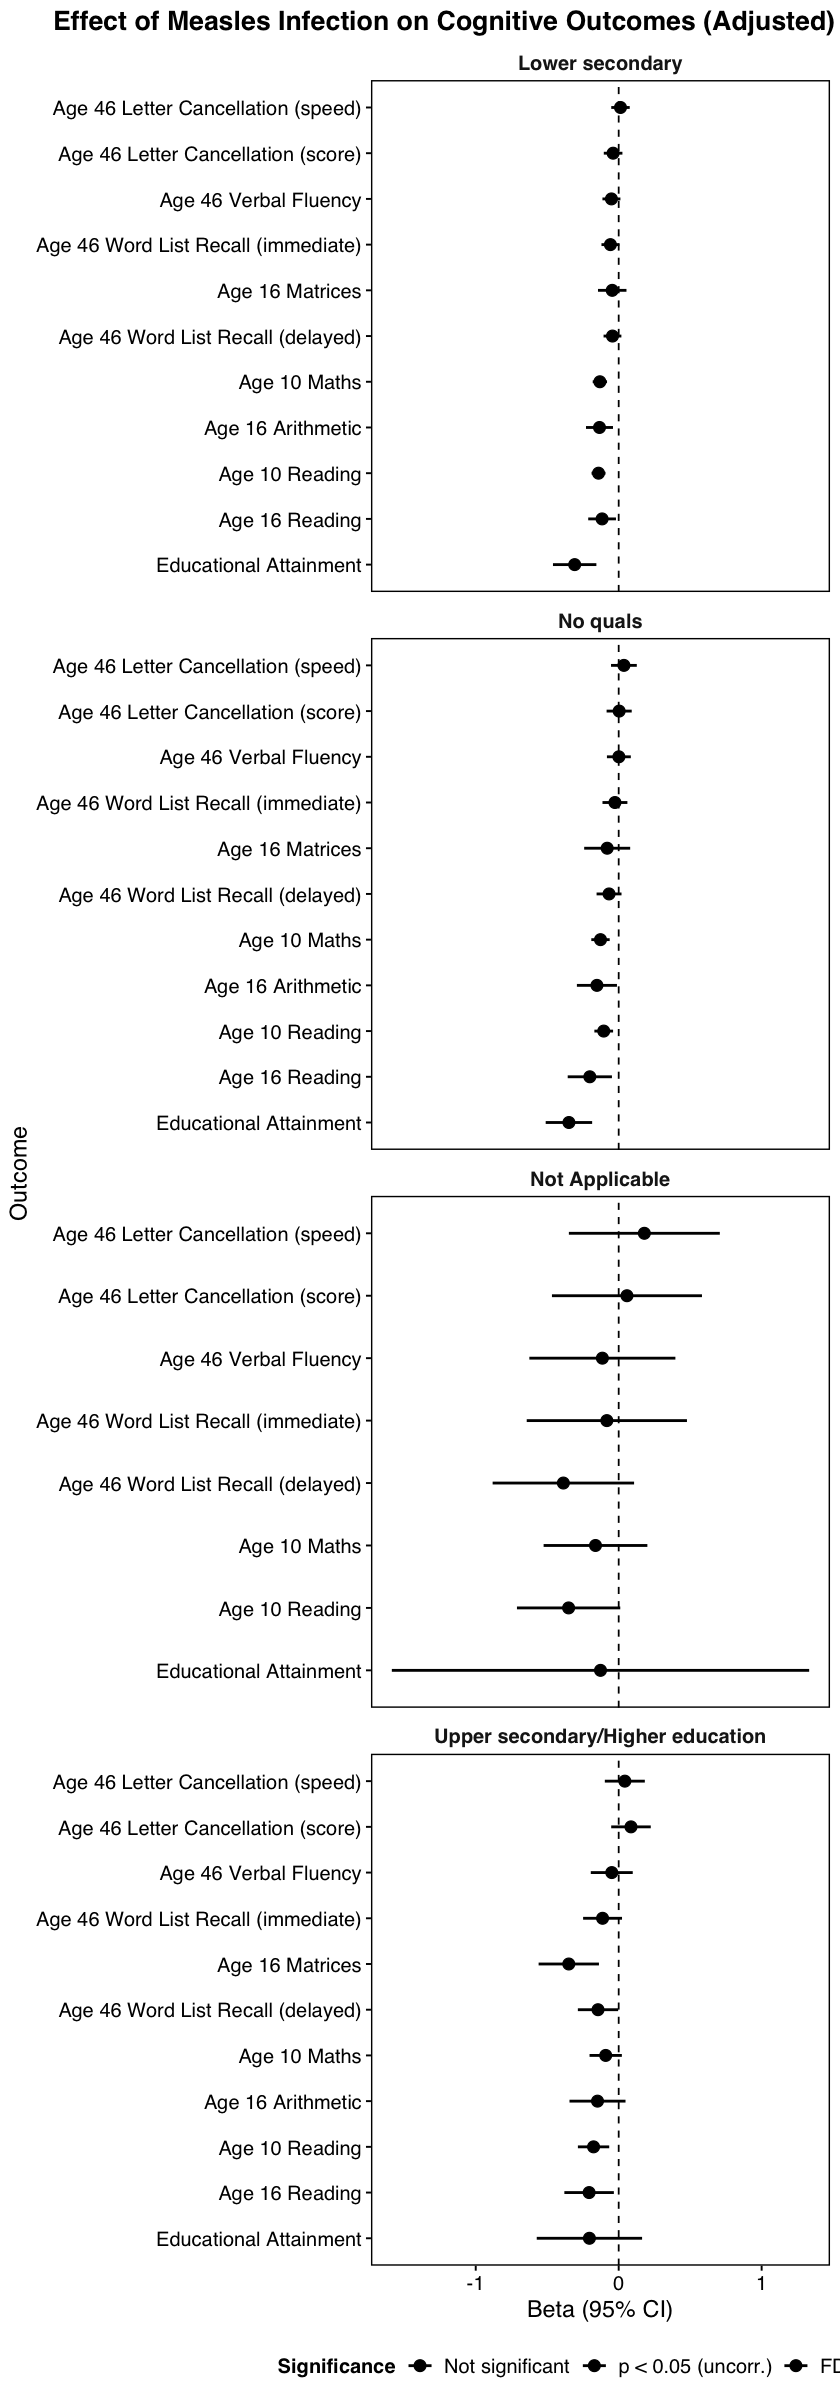

In [114]:
options(repr.plot.width = 7, repr.plot.height = 20)
cognitive_adj_by_parented_plot

In [115]:
cog_adj_df

term,estimate,std.error,statistic,p.value,conf.low,conf.high,model,n,outcome,outcome_type,fdr_family,significant,parent_ed,p_fdr,significant_fdr,outcome_label,sig_status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<lgl>,<chr>,<fct>
measlesinfectionYes,-0.104654333,0.03337324,-3.13587546,1.727967e-03,-0.17008785,-0.039220815,adjusted,3444,reading_score_raw10_z,continuous,cognitive,TRUE,No quals,6.335879e-03,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.140974707,0.02492132,-5.65679181,1.622939e-08,-0.18983073,-0.092118687,adjusted,5336,reading_score_raw10_z,continuous,cognitive,TRUE,Lower secondary,1.785233e-07,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.175808885,0.05583879,-3.14850837,1.687763e-03,-0.28537829,-0.066239483,adjusted,1066,reading_score_raw10_z,continuous,cognitive,TRUE,Upper secondary/Higher education,9.282696e-03,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.350311079,0.18243590,-1.92018715,5.728957e-02,-0.71164837,0.011026216,adjusted,140,reading_score_raw10_z,continuous,cognitive,FALSE,Not Applicable,4.583165e-01,FALSE,Age 10 Reading,Not significant
measlesinfectionYes,-0.127297034,0.03278218,-3.88311736,1.050749e-04,-0.19157166,-0.063022404,adjusted,3445,maths_score10_z,continuous,cognitive,TRUE,No quals,5.779118e-04,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.131575319,0.02554328,-5.15107381,2.683622e-07,-0.18165065,-0.081499990,adjusted,5332,maths_score10_z,continuous,cognitive,TRUE,Lower secondary,1.475992e-06,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.090898044,0.05758739,-1.57843649,1.147695e-01,-0.20389877,0.022102683,adjusted,1065,maths_score10_z,continuous,cognitive,FALSE,Upper secondary/Higher education,2.104107e-01,FALSE,Age 10 Maths,Not significant
measlesinfectionYes,-0.162290455,0.18323839,-0.88567936,3.776227e-01,-0.52521717,0.200636256,adjusted,140,maths_score10_z,continuous,cognitive,FALSE,Not Applicable,8.622577e-01,FALSE,Age 10 Maths,Not significant
measlesinfectionYes,-0.152274925,0.07138823,-2.13305365,3.324523e-02,-0.29242005,-0.012129798,adjusted,773,maths_score16_z,continuous,cognitive,TRUE,No quals,7.313950e-02,FALSE,Age 16 Arithmetic,p < 0.05 (uncorr.)


In [116]:
# ---- save ----
write.csv(all_results, "cog_adj_parented.csv", row.names = FALSE)

ggsave("cognitive_parented_plot.svg", plot = cognitive_adj_by_parented_plot, device = svglite, width = 7, height = 20)

Cog stratified by social index

In [117]:
## ONLY COGNITIVE OUTCOMES, STRATIFIED BY social index
# get only cognitive outcomes
cog_outcomes <- OUTCOME_SPEC %>%
  filter(fdr_family == "cognitive") %>%
  pull(name)

exposure     <- "measlesinfection"
exposure_pat <- paste0("^", exposure)

# income variable (change name if needed)
parented_var <- "socialindex"
parented_levels <- df_analytic %>%
  dplyr::pull(!!rlang::sym(parented_var)) %>%
  unique() %>%
  na.omit() %>%
  as.character()

# prepare storage
results_list <- vector("list", length(cog_outcomes))

# loop outcomes
for (i in seq_along(cog_outcomes)) {
  var <- cog_outcomes[i]
  typ <- "continuous"
  fam <- "cognitive"

  # covariates for this outcome
  current_covs <- covariates_reg
  if (var %in% cognitive_continuous_child) {
    current_covs <- setdiff(current_covs, "smoking_cat")
  }

  # ensure parented not treated as covariate (we're stratifying)
  current_covs <- setdiff(current_covs, parented_var)

  # collect per-parented-stratum results
  per_parented <- vector("list", length(parented_levels))

  for (j in seq_along(parented_levels)) {
    inc_level <- parented_levels[j]

    # subset and drop NA
    cols_needed <- c(var, exposure, current_covs, parented_var)
    df_model <- df_analytic %>%
      dplyr::select(dplyr::all_of(cols_needed)) %>%
      tidyr::drop_na() %>%
      dplyr::filter(!!rlang::sym(parented_var) == inc_level) %>%
      droplevels()

    if (nrow(df_model) == 0) {
      per_parented[[j]] <- tibble()
      next
    }

    # formulas
    f_unadj <- as.formula(paste(var, "~", exposure))
    f_adj   <- as.formula(paste(var, "~", paste(c(exposure, current_covs), collapse = " + ")))

    # fit with tryCatch to avoid breaking pipeline if a stratum fails
    fit_safe <- function(fml) {
      tryCatch(lm(fml, data = df_model), error = function(e) NULL)
    }

    m_unadj <- fit_safe(f_unadj)
    m_adj   <- fit_safe(f_adj)

    tid <- bind_rows(
      if (!is.null(m_unadj)) broom::tidy(m_unadj, conf.int = TRUE) %>% mutate(model = "unadjusted", n = nobs(m_unadj)) else tibble(),
      if (!is.null(m_adj))   broom::tidy(m_adj,   conf.int = TRUE) %>% mutate(model = "adjusted",   n = nobs(m_adj))   else tibble()
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 0 | conf.high < 0),
        !!parented_var := inc_level
      )

    per_parented[[j]] <- tid
  } # end parented loop

  results_list[[i]] <- bind_rows(per_parented)
} # end outcome loop

# ---- bind + FDR by (model x fdr_family x parented) ----
all_results <- bind_rows(results_list)

# ensure parented column exists
if (!parented_var %in% names(all_results)) all_results[[parented_var]] <- NA_character_

# FDR per (model x fdr_family x parented) for exposure rows only
all_results <- all_results %>%
  group_by(model, fdr_family, !!rlang::sym(parented_var)) %>%
  mutate(
    .is_exp   = grepl(exposure_pat, term),
    p_fdr     = replace(numeric(n()), .is_exp, if (any(.is_exp)) p.adjust(p.value[.is_exp], method = "fdr") else rep(NA_real_, sum(.is_exp))),
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

# ---- cognitive-only adjusted plot, faceted by parented ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

cognitive_adj_by_parented_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted) — stratified by parented",
    x = "Beta (95% CI)", y = "Outcome"
  ) +
  facet_wrap(vars(!!rlang::sym(parented_var)), scales = "free_y", ncol = 1) +
  my_custom_theme()


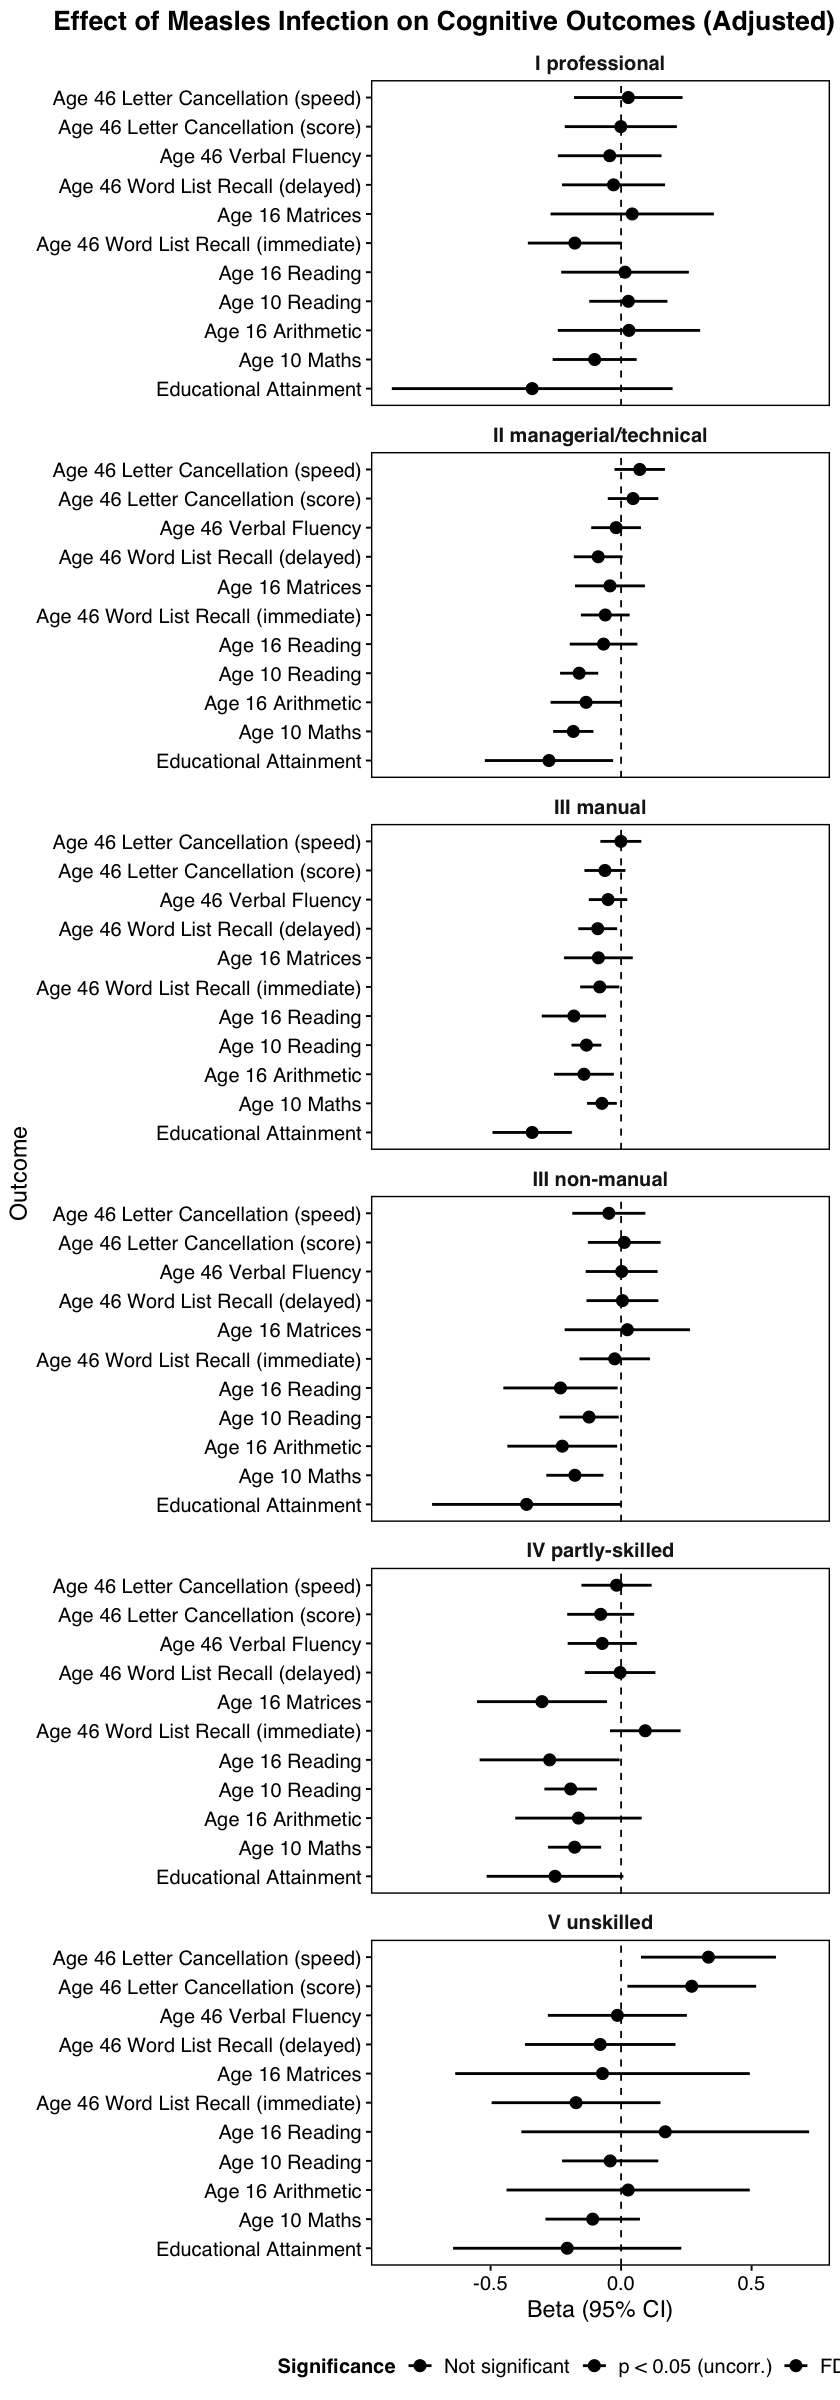

In [118]:
options(repr.plot.width = 7, repr.plot.height = 20)
cognitive_adj_by_parented_plot

In [119]:
cog_adj_df

term,estimate,std.error,statistic,p.value,conf.low,conf.high,model,n,outcome,outcome_type,fdr_family,significant,socialindex,p_fdr,significant_fdr,outcome_label,sig_status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<lgl>,<chr>,<fct>
measlesinfectionYes,-0.16068729,0.03728243,-4.3100003,1.702725e-05,-0.2337988,-0.087575807,adjusted,2277,reading_score_raw10_z,continuous,cognitive,TRUE,II managerial/technical,9.364989e-05,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.13283862,0.02919984,-4.5492922,5.534081e-06,-0.1900857,-0.075591533,adjusted,4236,reading_score_raw10_z,continuous,cognitive,TRUE,III manual,6.087489e-05,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.19327187,0.05128410,-3.7686513,1.710121e-04,-0.2938746,-0.092669166,adjusted,1411,reading_score_raw10_z,continuous,cognitive,TRUE,IV partly-skilled,1.881133e-03,TRUE,Age 10 Reading,FDR < 0.05
measlesinfectionYes,-0.12271339,0.05795305,-2.1174620,3.445772e-02,-0.2364318,-0.008995018,adjusted,1062,reading_score_raw10_z,continuous,cognitive,TRUE,III non-manual,1.040517e-01,FALSE,Age 10 Reading,p < 0.05 (uncorr.)
measlesinfectionYes,0.02781149,0.07626122,0.3646872,7.154929e-01,-0.1220058,0.177628760,adjusted,543,reading_score_raw10_z,continuous,cognitive,FALSE,I professional,9.923041e-01,FALSE,Age 10 Reading,Not significant
measlesinfectionYes,-0.04174358,0.09379718,-0.4450409,6.565121e-01,-0.2260968,0.142609625,adjusted,457,reading_score_raw10_z,continuous,cognitive,FALSE,V unskilled,9.027041e-01,FALSE,Age 10 Reading,Not significant
measlesinfectionYes,-0.18311877,0.03935765,-4.6526852,3.466566e-06,-0.2602999,-0.105937689,adjusted,2274,maths_score10_z,continuous,cognitive,TRUE,II managerial/technical,3.813223e-05,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.07334651,0.02905240,-2.5246287,1.161846e-02,-0.1303045,-0.016388512,adjusted,4239,maths_score10_z,continuous,cognitive,TRUE,III manual,3.195076e-02,TRUE,Age 10 Maths,FDR < 0.05
measlesinfectionYes,-0.17806886,0.05183217,-3.4354891,6.089877e-04,-0.2797470,-0.076390751,adjusted,1407,maths_score10_z,continuous,cognitive,TRUE,IV partly-skilled,3.349433e-03,TRUE,Age 10 Maths,FDR < 0.05


In [120]:
# ---- save ----
write.csv(all_results, "cog_adj_socialindex.csv", row.names = FALSE)

ggsave("cognitive_socialindex_plot.svg", plot = cognitive_adj_by_parented_plot, device = svglite, width = 7, height = 20)


Adjusted for adult education

In [79]:
covariates_reg = c("sex", "location", "socialindex",
               "maternal_smoking", "mother_age_at_birth",  
               "older_siblings", "younger_siblings", "income", "parent_ed", "smoking_cat", "adulteduc")

In [80]:
continuous_outcomes <- c("bmi_z", "waisthip_z", "bp_dia_z", "bp_sys_z")

continuous_biomarkers = c(continuousblood_std, continuous_outcomes)

In [81]:
# --- Set up outcomes and model family ---
outcomes <- c(continuous_biomarkers, "cmvigg")
family_map <- setNames(ifelse(outcomes == "cmvigg", "binomial", "continuous"), outcomes)

fit_once <- function(y) {
  fam <- family_map[[y]]
  fit <- function(fml) if (fam == "binomial") glm(fml, data = df_analytic, family = binomial) else lm(fml, data = df_analytic)

  f_unadj <- as.formula(paste(y, "~ measlesinfection"))
  f_adj   <- as.formula(paste(y, "~", paste(c("measlesinfection", covariates_reg), collapse = " + ")))

  bind_rows(
    tidy(fit(f_unadj), conf.int = TRUE, exponentiate = fam == "binomial") %>%
      mutate(model = "unadjusted", outcome = y, n = nobs(fit(f_unadj))),
    tidy(fit(f_adj),   conf.int = TRUE, exponentiate = fam == "binomial") %>%
      mutate(model = "adjusted",   outcome = y, n = nobs(fit(f_adj)))
  ) %>%
    mutate(
      family = fam,
      outcome_label = label_map[outcome],
      significant = case_when(
        term == "measlesinfectionYes" & family == "continuous" ~ conf.low > 0 | conf.high < 0,
        term == "measlesinfectionYes" & family == "binomial" ~ conf.low > 1 | conf.high < 1,
        TRUE ~ FALSE
      )
    )
    
}

# --- Run all models, stack, and apply FDR across outcomes within model type (adj vs unadj) ---
results_all <- map_dfr(outcomes, fit_once) %>%
  group_by(model) %>%
  mutate(
    # make an NA vector the size of the current group
    p_fdr = {
      idx <- term == "measlesinfectionYes"
      tmp <- rep(NA_real_, dplyr::n())
      if (any(idx)) tmp[idx] <- p.adjust(p.value[idx], method = "fdr")
      tmp
    },
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup()

results_all <- results_all %>%
  mutate(
    sig_status = case_when(
      term == "measlesinfectionYes" & significant_fdr ~ "FDR < 0.05",
      term == "measlesinfectionYes" & significant     ~ "p < 0.05 (uncorr.)",
      term == "measlesinfectionYes"                   ~ "Not significant",
      TRUE                                            ~ NA_character_
    ),
    # fix the display order in the legend
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

# --- Plots ---
bloodcontinuousplot <- results_all %>%
  filter(family == "continuous", model == "adjusted", term == "measlesinfectionYes") %>%
  ggplot(aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 2.8) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",   # grey
      "p < 0.05 (uncorr.)"    = "black", # green
      "FDR < 0.05"            = "black"   # blue
    ),
    drop = FALSE
  ) +
  labs(title = "Effect of Measles on Continuous Biomarkers",
       x = "Beta (95% CI)", y = "Outcome") +
  my_custom_theme()

bloodcategoricalplot <- results_all %>%
  filter(family == "binomial", model == "adjusted", term == "measlesinfectionYes") %>%
  ggplot(aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(title = "Odds Ratios for Binary Biomarkers",
       x = "Odds Ratio (95% CI)", y = "Outcome") +
  my_custom_theme()


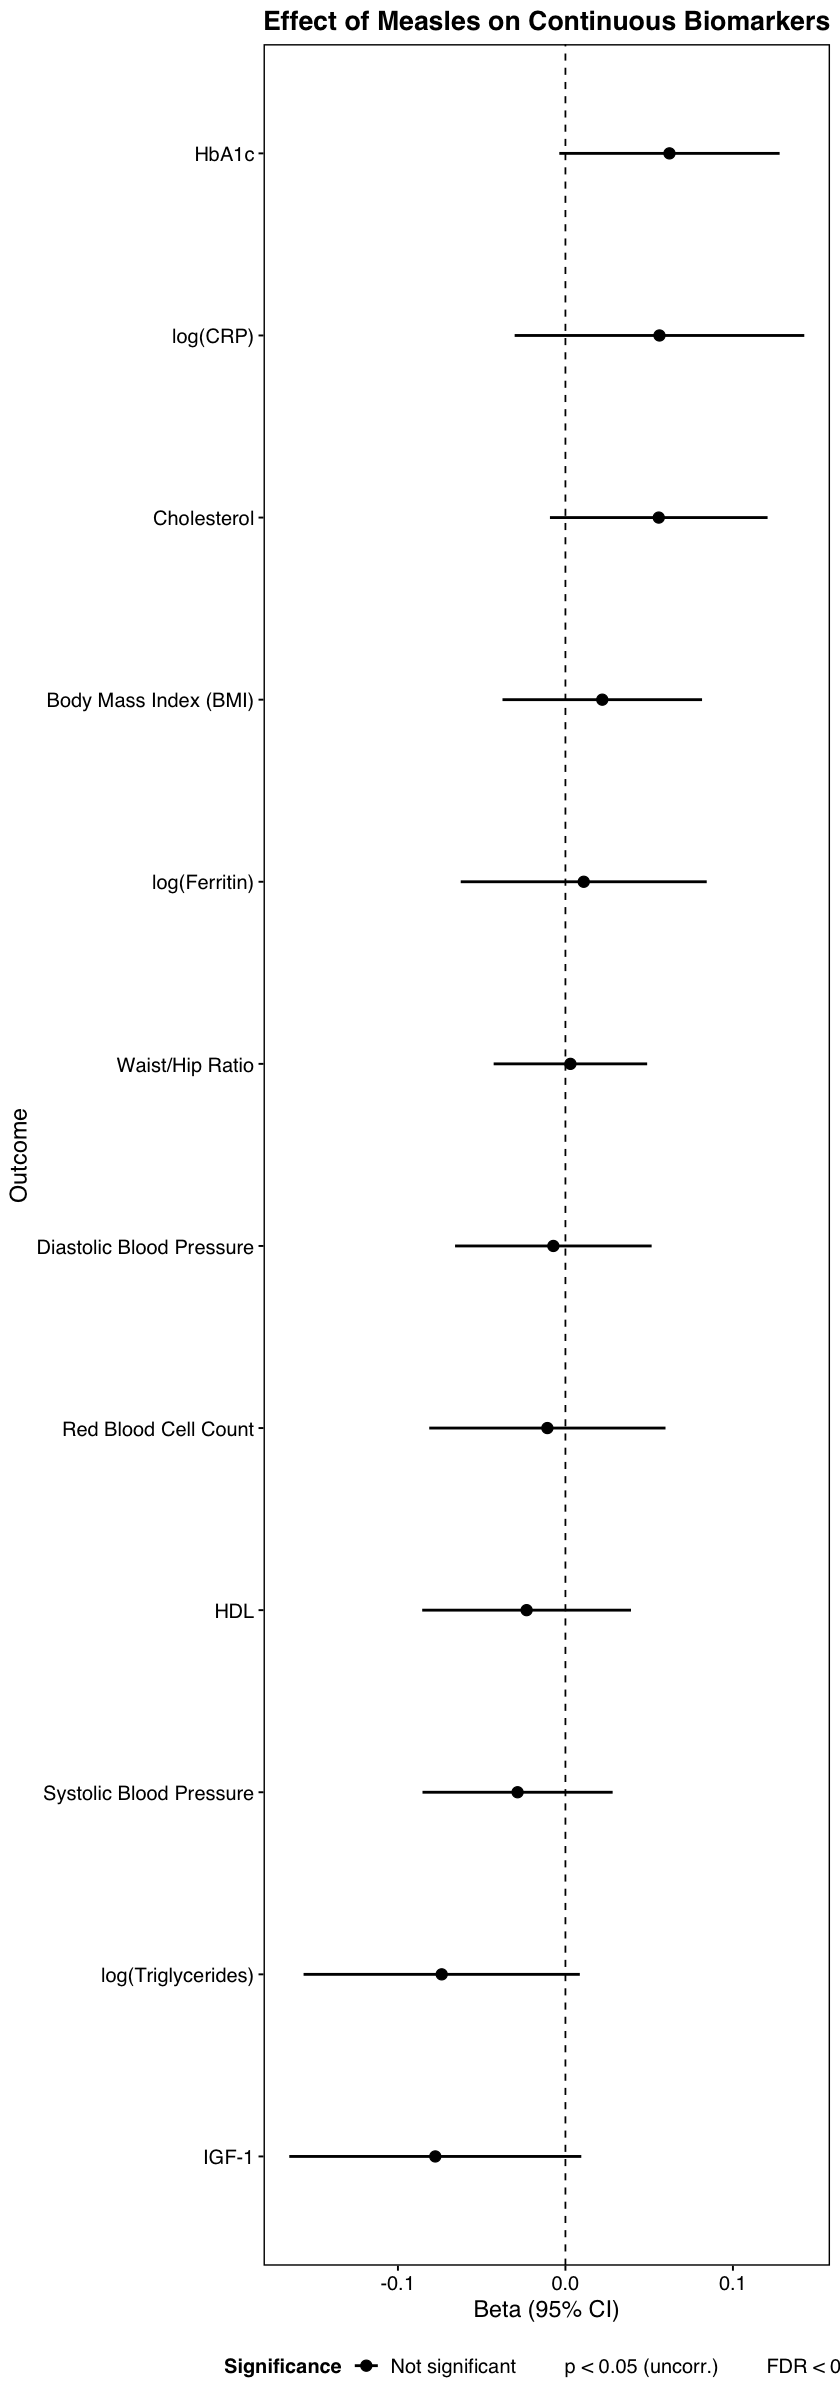

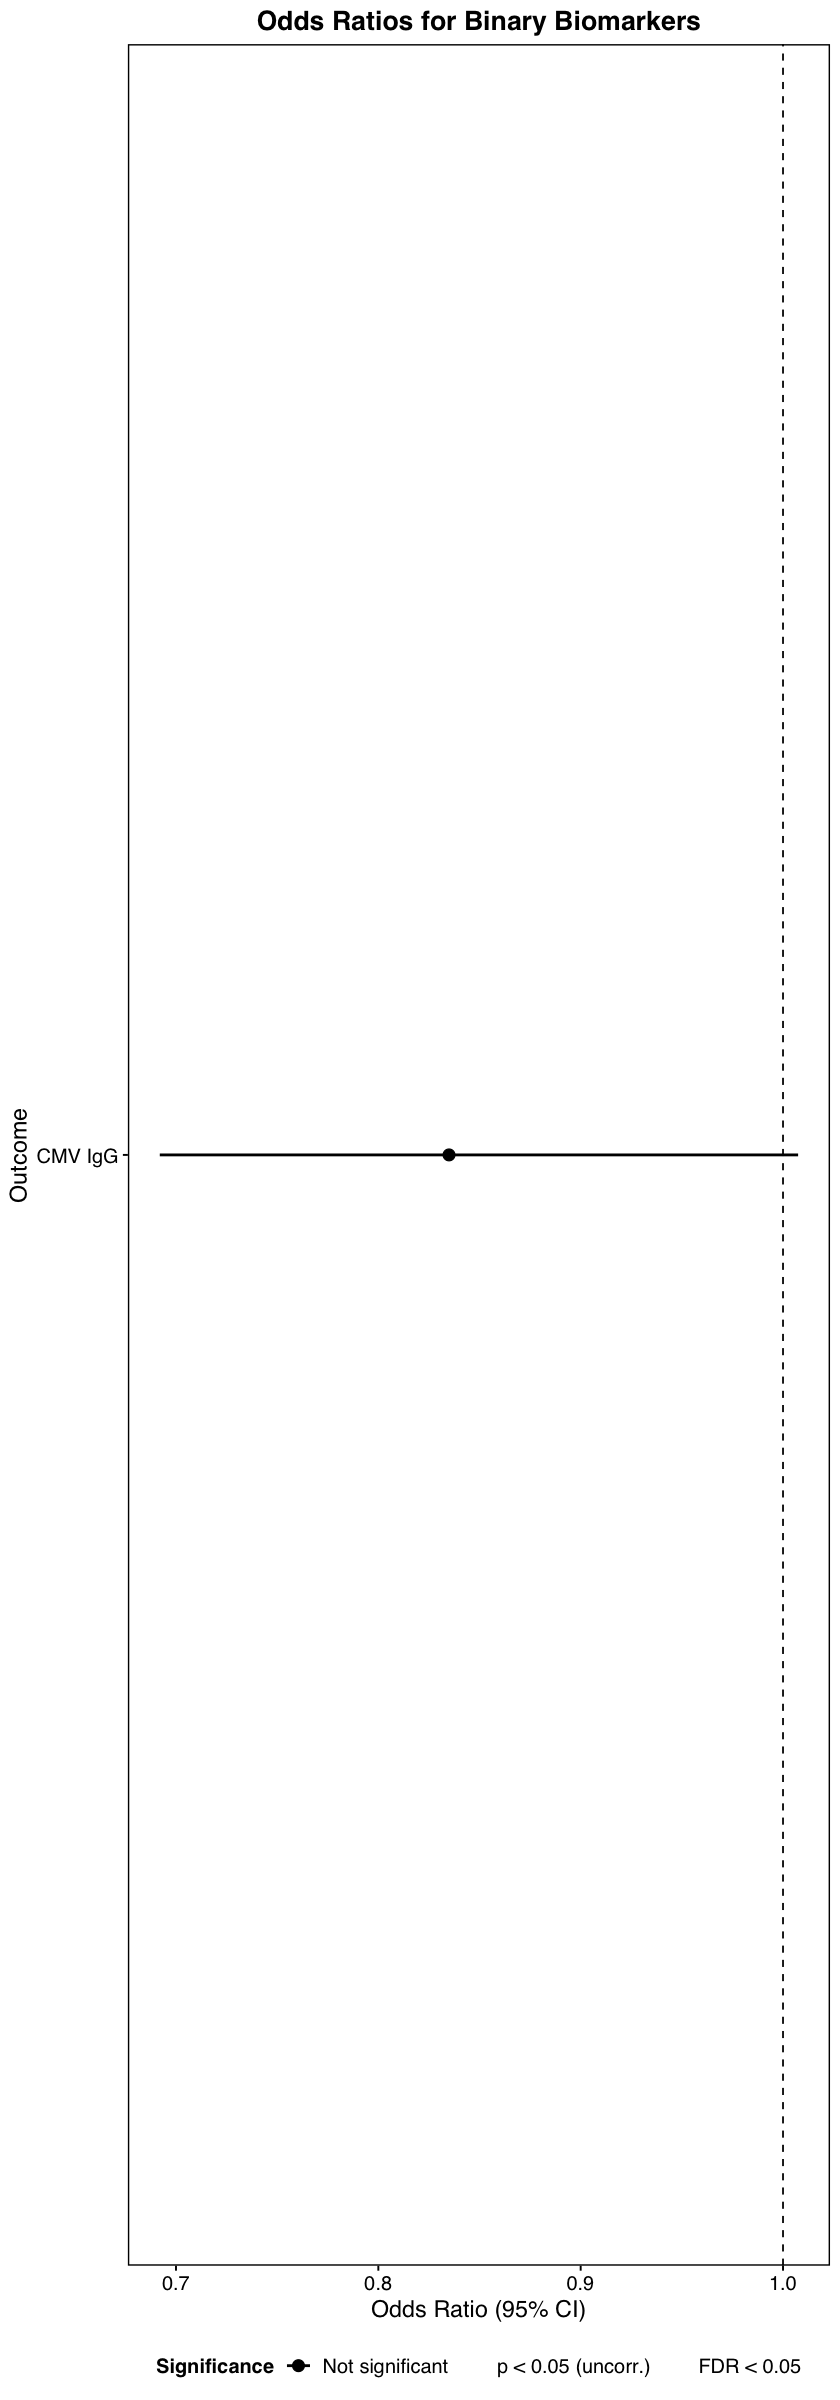

In [82]:
bloodcontinuousplot
bloodcategoricalplot

In [83]:
write.csv(results_all, "biomarker_adulteduc.csv", row.names = FALSE)
ggsave("biomarkercontinuousplot_adulteduc.svg", plot = bloodcontinuousplot, device = svglite, width = 6, height = 4)
ggsave("biomarkercategoricalplot_adulteduc.svg", plot = bloodcategoricalplot, device = svglite, width = 6, height = 2)

In [86]:
categorical_outcomes <- c(
  "diabetes", "hypertension"
)

cognitive_continuous_adult <- c( 
  "wordlist_immediate46_z", "wordlist_delayed46_z",
  "animal_naming46_z", "letter_correct46_z", "letter_speed46_z")

cognitive_continuous_child <- c(
  "reading_score_raw10_z", "maths_score10_z",
  "maths_score16_z", "matrices_score16_z", "reading_score_total16_z")


In [87]:
## REGRESSIONS AND FOREST PLOTS
# Define families for FDR
OUTCOME_SPEC <- bind_rows(
  tibble(name = categorical_outcomes, type = "binary",     fdr_family = "endpoint"),
  tibble(name = cognitive_continuous_child, type = "continuous", fdr_family = "cognitive"),
  tibble(name = cognitive_continuous_adult, type = "continuous", fdr_family = "cognitive")
)

exposure     <- "measlesinfection"
exposure_pat <- paste0("^", exposure)

# ---- single pass loop ----
results_list <- vector("list", nrow(OUTCOME_SPEC))

for (i in seq_len(nrow(OUTCOME_SPEC))) {
  var <- OUTCOME_SPEC$name[i]
  typ <- OUTCOME_SPEC$type[i]
  fam <- OUTCOME_SPEC$fdr_family[i]

  # covariates
  current_covs <- covariates_reg
    if (OUTCOME_SPEC$name[i] %in% cognitive_continuous_child) {
      current_covs <- setdiff(current_covs, c("smoking_cat", "adulteduc"))
    }

  # model data
  cols_needed <- c(var, exposure, current_covs)
  df_model <- df_analytic %>%
    dplyr::select(dplyr::all_of(cols_needed)) %>%
    tidyr::drop_na() %>%
    droplevels()

  # formulas
  f_unadj <- as.formula(paste(var, "~", exposure))
  f_adj   <- as.formula(paste(var, "~", paste(c(exposure, current_covs), collapse = " + ")))

  if (typ == "binary") {
    m_unadj <- glm(f_unadj, data = df_model, family = binomial)
    m_adj   <- glm(f_adj,   data = df_model, family = binomial)

    tid <- bind_rows(
      tidy(m_unadj, exponentiate = TRUE, conf.int = TRUE) %>%
        mutate(model = "unadjusted", n = nobs(m_unadj)),
      tidy(m_adj,   exponentiate = TRUE, conf.int = TRUE) %>%
        mutate(model = "adjusted",   n = nobs(m_adj))
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 1 | conf.high < 1)
      )
} else { # continuous
    m_unadj <- lm(f_unadj, data = df_model)
    m_adj   <- lm(f_adj,   data = df_model)

    tid <- bind_rows(
      tidy(m_unadj, conf.int = TRUE) %>% mutate(model = "unadjusted", n = nobs(m_unadj)),
      tidy(m_adj,   conf.int = TRUE) %>% mutate(model = "adjusted",   n = nobs(m_adj))
    ) %>%
      mutate(
        outcome      = var,
        outcome_type = typ,
        fdr_family   = fam,
        significant  = grepl(exposure_pat, term) & (conf.low > 0 | conf.high < 0)
      )

  }
  results_list[[i]] <- tid
}



# ---- bind + FDR by family ----
all_results <- bind_rows(results_list)

# FDR per (model x fdr_family), ONLY for exposure term rows
all_results <- all_results %>%
  group_by(model, fdr_family) %>%
  mutate(
    .is_exp   = grepl(exposure_pat, term),
    p_fdr     = replace(numeric(n()), .is_exp, p.adjust(p.value[.is_exp], method = "fdr")),
    significant_fdr = !is.na(p_fdr) & p_fdr < 0.05
  ) %>%
  ungroup() %>%
  select(-.is_exp)

#### PLOTS
# ---- adjusted ORs for endpoints ----
forest_df <- all_results %>%
  filter(outcome_type == "binary",
         fdr_family == "endpoint",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

outcomescategoricalor <- ggplot(
  forest_df,
  aes(x = estimate, y = fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",     # grey
      "p < 0.05 (uncorr.)"    = "black",#
      "FDR < 0.05"            = "black"  # 
    ),
    drop = FALSE
  ) +
  labs(title = "Odds Ratios for Measles Infection (Adjusted)",
       x = "Odds Ratio (95% CI)", y = "Outcome") +
  my_custom_theme()



# ---- Cognitive outcomes (adjusted-only) ----
cog_adj_df <- all_results %>%
  filter(outcome_type == "continuous",
         fdr_family == "cognitive",
         model == "adjusted",
         grepl(exposure_pat, term)) %>%
  mutate(
    outcome_label = label_map[outcome],
    sig_status = case_when(
      significant_fdr ~ "FDR < 0.05",           # blue
      significant     ~ "p < 0.05 (uncorr.)",   # green
      TRUE            ~ "Not significant"       # grey
    ),
    sig_status = factor(sig_status,
                        levels = c("Not significant", "p < 0.05 (uncorr.)", "FDR < 0.05"))
  )

cognitive_adj_plot <- ggplot(
  cog_adj_df,
  aes(x = estimate, y = forcats::fct_reorder(outcome_label, estimate), color = sig_status)
) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0, linewidth = 0.8) +
  geom_point(size = 3) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_color_manual(
    name = "Significance",
    values = c(
      "Not significant"       = "black",
      "p < 0.05 (uncorr.)"    = "black",
      "FDR < 0.05"            = "black"
    ),
    drop = FALSE
  ) +
  labs(
    title = "Effect of Measles Infection on Cognitive Outcomes (Adjusted)",
    x = "Beta (95% CI)", y = "Outcome") + 
    my_custom_theme()

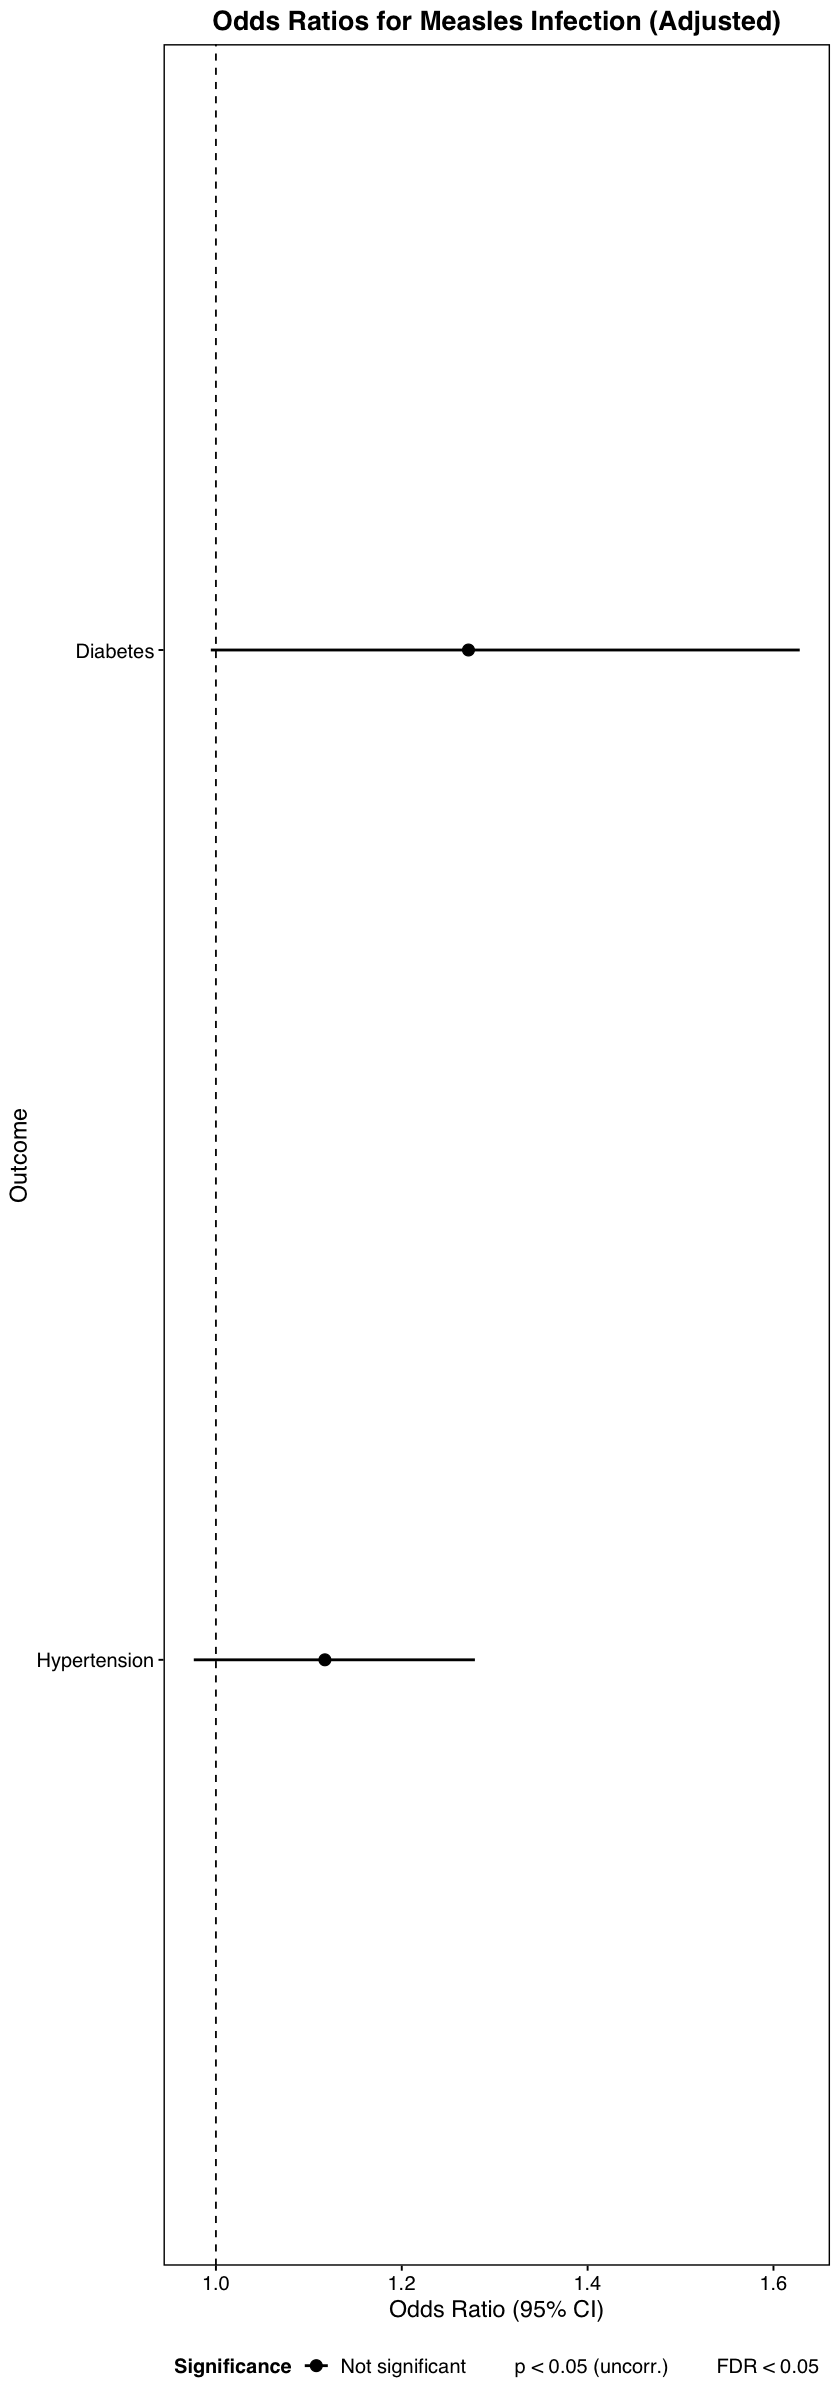

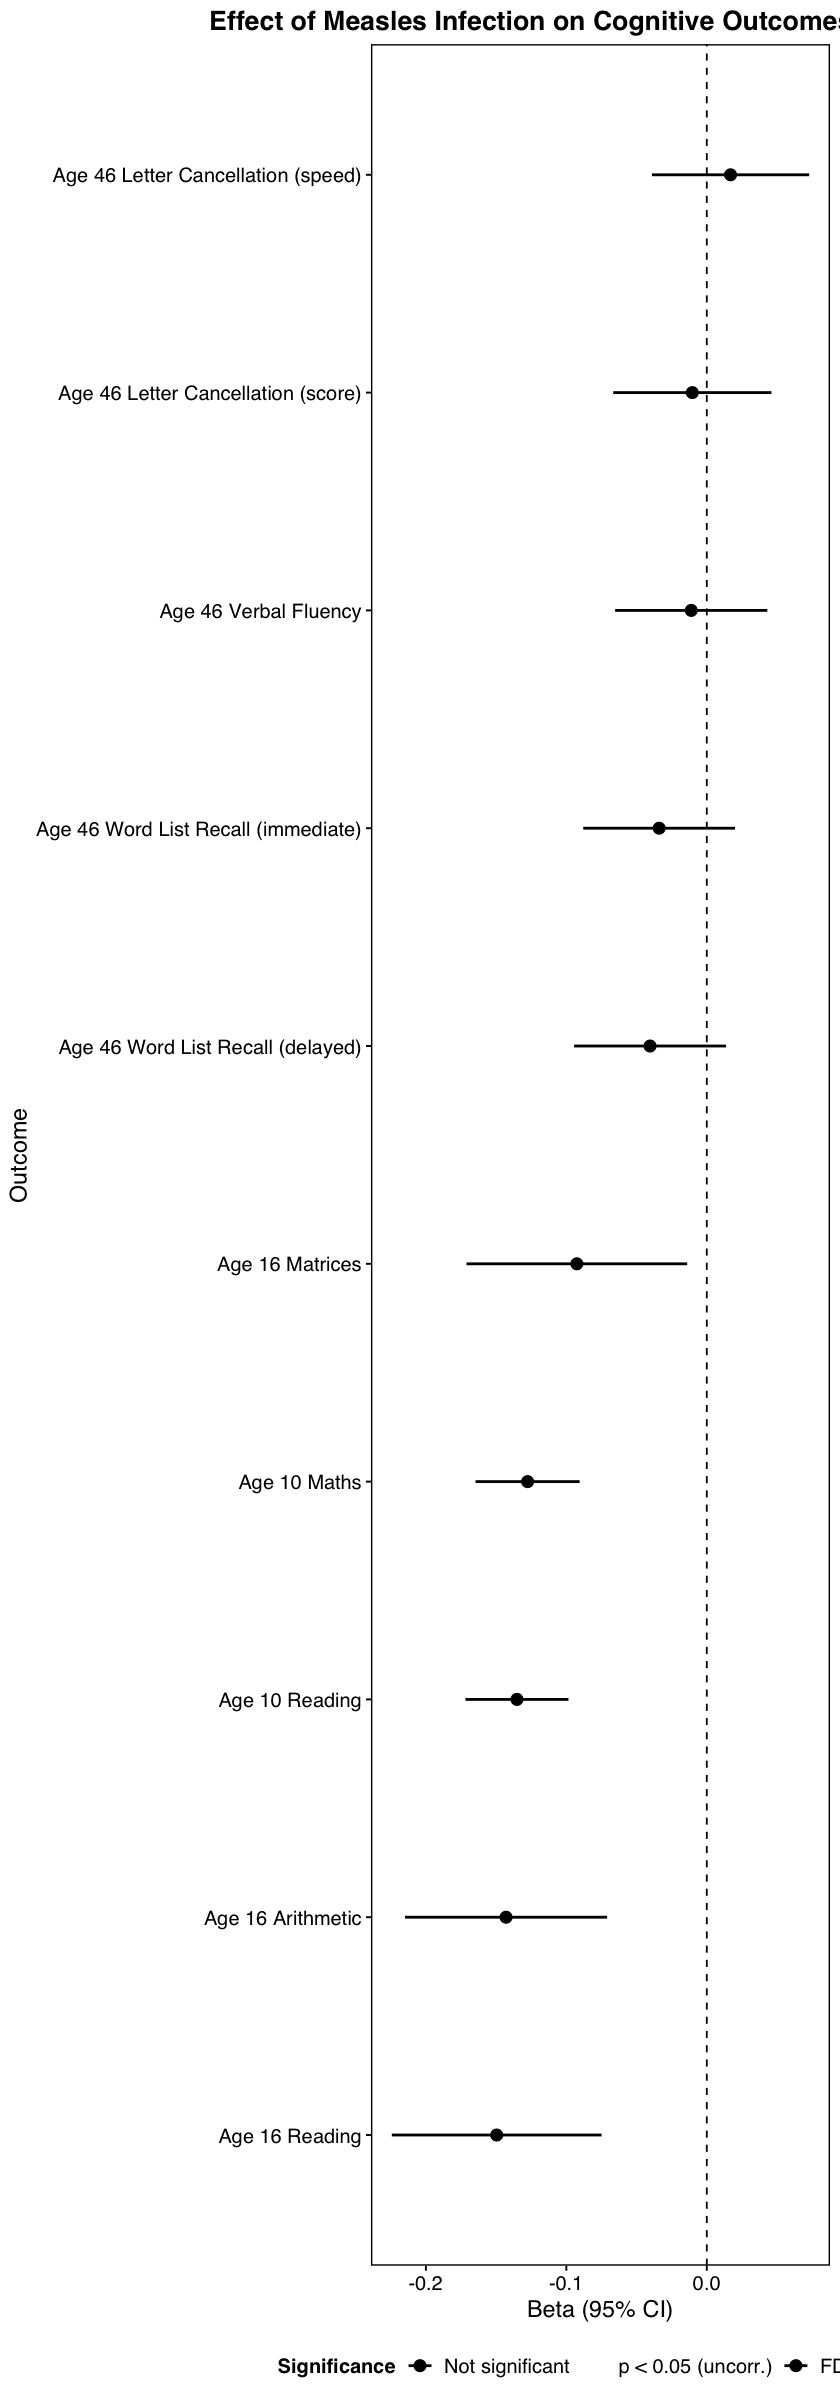

In [88]:
outcomescategoricalor
cognitive_adj_plot

In [89]:
# ---- save ----
write.csv(all_results, "all_outcomes_fdr_by_family_adulteduc.csv", row.names = FALSE)

ggsave("outcomescategoricalor_adulteduc.svg", plot = outcomescategoricalor, device = svglite, width = 6, height = 3)

ggsave("cognitive_adjusted_plot_adulteduc.svg", plot = cognitive_adj_plot, device = svglite, width = 6, height = 5)
